In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/chest_xray_platform', exist_ok=True)
os.chdir('/content/drive/MyDrive')
print("Working directory now:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory now: /content/drive/MyDrive


In [5]:
import os
import subprocess
import sys
from pathlib import Path

# Əsas qovluq
root = Path("chest_xray_platform")

folders = [
    "data/raw",
    "dataset/train", "dataset/val", "dataset/test",
    "experiments/chest_MobileNetV2",
    "dashboard/pages",
]

# Qovluqların yaradılması
for f in folders:
    (root / f).mkdir(parents=True, exist_ok=True)

packages = [
    "tensorflow", "imagehash", "albumentations", "pillow", "requests",
    "numpy", "pandas", "matplotlib", "seaborn",
    "scikit-learn", "streamlit",
]
subprocess.run([sys.executable, "-m", "pip", "install", *packages, "--break-system-packages"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'tensorflow', 'imagehash', 'albumentations', 'pillow', 'requests', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'streamlit', '--break-system-packages'], returncode=0)

In [3]:
#Data Collection
import os
import tarfile
from pathlib import Path
import requests

nih_dir = Path("chest_xray_platform/data/raw/nih_chestxray14")
nih_dir.mkdir(parents=True, exist_ok=True)

IA_BASE = "https://archive.org/download/ChestXray-NIHCC/ChestXray-NIHCC"

def download(url, out_path, chunk_size=1 << 20):
    if out_path.exists():
        return
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                f.write(chunk)


images_present = any(nih_dir.glob("**/*.png"))

if images_present:
    print("Image files already present locally -- skipping image download/extract.")
else:
    urls = [f"{IA_BASE}/images_{i:03d}.tar.gz" for i in range(1, 3)]
    archive_paths = []
    for i, url in enumerate(urls):
        out_path = nih_dir / f"images_{i + 1:03d}.tar.gz"
        print(f"Checking/Downloading {out_path.name}...")
        download(url, out_path)
        archive_paths.append(out_path)
    for archive in archive_paths:
        print(f"Extracting {archive.name}...")
        with tarfile.open(archive, "r:gz") as tar:
            tar.extractall(nih_dir, filter="data")
    print("Images downloaded and extracted successfully!")

if (nih_dir / "Data_Entry_2017.csv").exists() and (nih_dir / "BBox_List_2017.csv").exists():
    print("Metadata CSVs already present locally -- skipping.")
else:
    print("Downloading metadata CSVs...")
    download(f"{IA_BASE}/Data_Entry_2017.csv", nih_dir / "Data_Entry_2017.csv")
    download(f"{IA_BASE}/BBox_List_2017.csv", nih_dir / "BBox_List_2017.csv")
    print("Metadata downloads complete.")

Image files already present locally -- skipping image download/extract.
Metadata CSVs already present locally -- skipping.


In [ ]:
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def _check_valid(p):
    try:
        with Image.open(p) as im:
            im.verify()
        return p, True
    except Exception:
        return p, False

def step1_validate(image_paths, max_workers=16):
    """Zədələnmiş və ya yarımçıq yüklənmiş şəkilləri təmizləyir (paralel)."""
    valid = []
    corrupt = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for p, ok in tqdm(ex.map(_check_valid, image_paths), total=len(image_paths), desc="Validating"):
            if ok:
                valid.append(p)
            else:
                corrupt += 1
    print(f"Validated {len(valid)} images, removed {corrupt} corrupt files")
    return valid


def run_cleaning(records):
    paths = [r["path"] for r in records]
    valid_paths = set(step1_validate(paths))
    records = [r for r in records if r["path"] in valid_paths]

    deduped_paths = set(step3_deduplicate([r["path"] for r in records]))
    records = [r for r in records if r["path"] in deduped_paths]
    return records

In [ ]:
IMG_SIZE = (224, 224)

def step2_resize_letterbox(img, size=IMG_SIZE):
    img.thumbnail(size, Image.LANCZOS) # Şəklin keyfiyyətini qoruyan ölçmə
    background = Image.new("RGB", size, (0, 0, 0))
    offset = ((size[0] - img.width) // 2, (size[1] - img.height) // 2)
    background.paste(img, offset)
    return background


In [ ]:
import imagehash
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


def _phash(p):
    try:
        return p, imagehash.phash(Image.open(p))
    except Exception:
        return p, None


class BKTree:
    """Enables near-duplicate lookup in ~O(log n) instead of comparing
    against every previously kept hash."""
    def __init__(self, distance_fn):
        self.distance_fn = distance_fn
        self.tree = None

    def add(self, item):
        node = (item, {})
        if self.tree is None:
            self.tree = node
            return
        cur = self.tree
        while True:
            d = self.distance_fn(item, cur[0])
            if d in cur[1]:
                cur = cur[1][d]
            else:
                cur[1][d] = node
                return

    def find_within(self, item, threshold):
        if self.tree is None:
            return False
        candidates = [self.tree]
        while candidates:
            cur = candidates.pop()
            d = self.distance_fn(item, cur[0])
            if d <= threshold:
                return True
            lo, hi = d - threshold, d + threshold
            for dist, child in cur[1].items():
                if lo <= dist <= hi:
                    candidates.append(child)
        return False


def step3_deduplicate(image_paths, threshold=5, max_workers=16):
    """Hər iki şəkil arasındakı fərq <= threshold-dırsa, onlar eynidir (BK-tree, sürətli)."""
    hashes = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for p, h in tqdm(ex.map(_phash, image_paths), total=len(image_paths), desc="Hashing"):
            if h is not None:
                hashes[p] = h

    tree = BKTree(lambda a, b: a - b)
    keep = []
    for p, h in tqdm(hashes.items(), desc="Deduplicating"):
        if tree.find_within(h, threshold):
            continue
        tree.add(h)
        keep.append(p)

    print(f"Deduplication: {len(image_paths)} -> {len(keep)}")
    return keep

In [ ]:
from collections import Counter # Elementlərin sayını hesablamaq üçün
import numpy as np
MIN_CLASS_SIZE = 200

def step4_eda_report_multilabel(records, pathology_names, min_class_size=MIN_CLASS_SIZE): # Hər xəstəlikdən neçə dənə olduğunu hesablayır
    label_matrix = np.stack([r["labels"] for r in records])
    counts = label_matrix.sum(axis=0)
    print("Per-pathology positive counts:")
    for name, n in zip(pathology_names, counts):
        flag = " [IMBALANCED]" if n < min_class_size else ""
        print(f"  {name}: {int(n)}{flag}")
    print(f"  No Finding (all-zero): {int((label_matrix.sum(axis=1) == 0).sum())}")
    return counts


In [ ]:
def compute_pos_weights(records, pathology_names): # balanssızlığı tənzimləmək üçün
    label_matrix = np.stack([r["labels"] for r in records])
    pos = label_matrix.sum(axis=0)
    neg = len(records) - pos
    pos_weight = np.clip(neg / np.maximum(pos, 1), 1.0, 50.0)
    return dict(zip(pathology_names, pos_weight.tolist()))


In [ ]:
import random
SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}

def step6_split(items, ratios=SPLIT_RATIOS, seed=42):
    random.seed(seed)
    random.shuffle(items)
    n = len(items)
    n_train = int(n * ratios["train"])
    n_val = int(n * ratios["val"])
    return {
        "train": items[:n_train],
        "val": items[n_train:n_train + n_val],
        "test": items[n_train + n_val:],
    }


In [ ]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm


def _process_one(args):
    entry, out_dir, pathology_names, split = args
    src_path = Path(entry["path"])
    if not src_path.exists():
        return None
    img = Image.open(src_path).convert("RGB")
    img = step2_resize_letterbox(img)
    fname = src_path.name
    img.save(out_dir / fname)
    row = {"filename": fname, "split": split, "source": "chest", "augmented": False}
    row.update({name: int(v) for name, v in zip(pathology_names, entry["labels"])})
    return row


def step7_organize_multilabel(split_items, pathology_names, out_root="dataset", max_workers=16):
    manifest_rows = []
    for split, items in split_items.items():
        out_dir = Path(out_root) / split / "chest"
        out_dir.mkdir(parents=True, exist_ok=True)
        tasks = [(entry, out_dir, pathology_names, split) for entry in items]
        with ThreadPoolExecutor(max_workers=max_workers) as ex:
            for row in tqdm(ex.map(_process_one, tasks), total=len(tasks), desc=f"Organizing[{split}]"):
                if row is not None:
                    manifest_rows.append(row)
    return manifest_rows

In [ ]:
def step8_normalize(train_image_paths):
    means, stds = [], []
    for p in train_image_paths[:2000]:
        arr = np.asarray(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
        means.append(arr.mean(axis=(0, 1)))
        stds.append(arr.std(axis=(0, 1)))
    return np.mean(means, axis=0).tolist(), np.mean(stds, axis=0).tolist()


In [ ]:
import pandas as pd

def step9_manifest(rows, out_path="dataset/split_manifest_chest.csv"):
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    print(f"Manifest written: {out_path} ({len(df)} rows)")

def step10_report(rows, pathology_names):
    df = pd.DataFrame(rows)
    print("\n=== Final Summary ===")
    print(df.groupby(["source", "split"]).size())
    print("\nPer-pathology positive counts (train split):")
    train_df = df[df["split"] == "train"]
    print(train_df[pathology_names].sum())


In [6]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

PATHOLOGY_NAMES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
    "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia",
]

def multi_hot(finding_str):
    vec = np.zeros(len(PATHOLOGY_NAMES), dtype=np.float32)
    for label in finding_str.split("|"):
        if label in PATHOLOGY_NAMES:
            vec[PATHOLOGY_NAMES.index(label)] = 1.0
    return vec


# if __name__ == "__main__":
#     nih_dir = Path("chest_xray_platform/data/raw/nih_chestxray14")
#     images_dir = nih_dir / "images"

#     labels_df = pd.read_csv(nih_dir / "Data_Entry_2017.csv")

#     # Vectorized instead of iterrows(): build multi-hot matrix once, then
#     # filter to rows whose image actually exists on disk.
#     label_matrix = np.stack([multi_hot(s) for s in labels_df["Finding Labels"]])
#     img_paths = [images_dir / name for name in labels_df["Image Index"]]
#     exists_mask = [p.exists() for p in img_paths]

#     records = [
#         {"path": p, "labels": lab}
#         for p, lab, keep in zip(img_paths, label_matrix, exists_mask) if keep
#     ]

#     print(f"Loaded {len(records)} labeled records")

#     records = run_cleaning(records)
#     step4_eda_report_multilabel(records, PATHOLOGY_NAMES)

#     pos_weights = compute_pos_weights(records, PATHOLOGY_NAMES)
#     print("Pos weights:", pos_weights)

#     splits = step6_split(records)
#     rows = step7_organize_multilabel(splits, PATHOLOGY_NAMES)

#     train_paths = [Path("dataset/train/chest") / r["filename"] for r in rows if r["split"] == "train"]
#     mean, std = step8_normalize(train_paths)

#     step9_manifest(rows)
#     step10_report(rows, PATHOLOGY_NAMES)

#     with open("dataset/stats.json", "w") as f:
#         json.dump({"mean": mean, "std": std, "pos_weights": pos_weights}, f, indent=2)

Exploratory Data Analysis

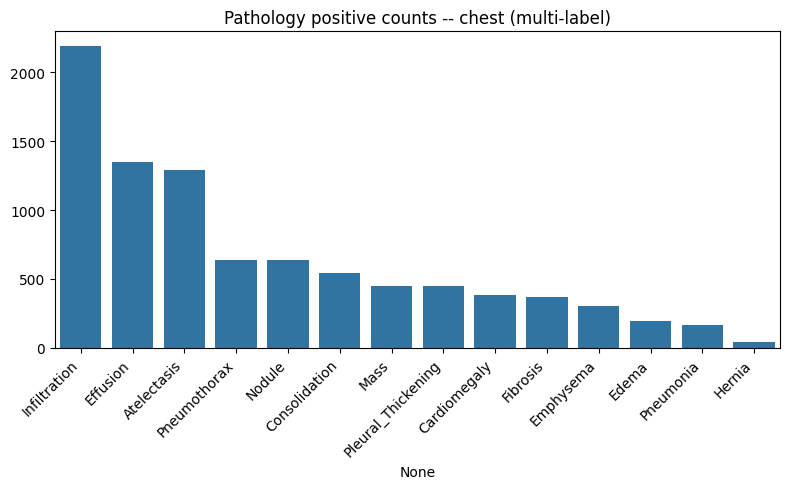

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_class_distribution(manifest_csv, pathology_names, out_path="assets/eda/class_distribution.png"):
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    df = pd.read_csv(manifest_csv)
    counts = df[pathology_names].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title("Pathology positive counts -- chest (multi-label)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()

plot_class_distribution("dataset/split_manifest_chest.csv", PATHOLOGY_NAMES)

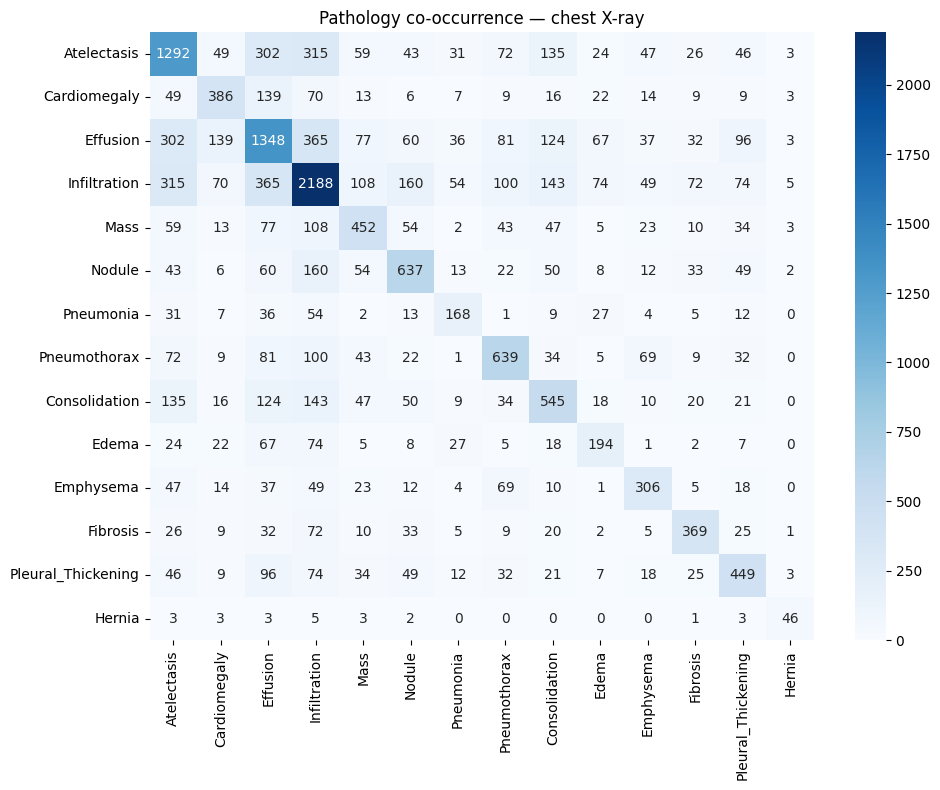

In [ ]:
def label_cooccurrence_heatmap(chest_labels_df, pathology_cols, out_path="assets/eda/cooccurrence.png"):
    co = chest_labels_df[pathology_cols].T.dot(chest_labels_df[pathology_cols])
    plt.figure(figsize=(10, 8))
    sns.heatmap(co, annot=True, fmt="d", cmap="Blues")
    plt.title("Pathology co-occurrence — chest X-ray")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()
label_cooccurrence_heatmap(pd.read_csv("dataset/split_manifest_chest.csv"), PATHOLOGY_NAMES)

Skip

In [ ]:
# #Data Loading: train_ds / val_ds / test_ds (multi-label, from manifest CSV)
# import json
# import tensorflow as tf
# import pandas as pd

# with open("dataset/stats.json") as f:
#     _stats = json.load(f)
# CHANNEL_MEAN = tf.constant(_stats["mean"], dtype=tf.float32)
# CHANNEL_STD = tf.constant(_stats["std"], dtype=tf.float32)
# POS_WEIGHTS = tf.constant([_stats["pos_weights"][n] for n in PATHOLOGY_NAMES], dtype=tf.float32)

# BATCH_SIZE = 32

# def load_and_preprocess(path, labels):
#     img = tf.io.read_file(path)
#     img = tf.image.decode_png(img, channels=3)
#     img = tf.image.resize(img, IMG_SIZE)
#     img = (tf.cast(img, tf.float32) / 255.0 - CHANNEL_MEAN) / CHANNEL_STD
#     return img, labels

# def make_chest_dataset(split, shuffle):
#     manifest = pd.read_csv("dataset/split_manifest_chest.csv")
#     split_df = manifest[manifest["split"] == split]
#     assert len(split_df) > 0, f"No rows found for split='{split}' in split_manifest_chest.csv"
#     paths = ("dataset/" + split + "/chest/" + split_df["filename"]).tolist()
#     labels = split_df[PATHOLOGY_NAMES].values.astype("float32")

#     ds = tf.data.Dataset.from_tensor_slices((paths, labels))
#     if shuffle:
#         ds = ds.shuffle(buffer_size=max(len(paths), 1), seed=42)
#     ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
#     return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# train_ds = make_chest_dataset("train", shuffle=True)
# val_ds = make_chest_dataset("val", shuffle=False)
# test_ds = make_chest_dataset("test", shuffle=False)


Updated Data loading

In [7]:
import shutil
from pathlib import Path

LOCAL_ROOT = Path("/content/dataset")
DRIVE_DATASET = Path("dataset")  # relative to cwd /content/drive/MyDrive — this is the real location

if not LOCAL_ROOT.exists():
    print("Copying dataset to local disk, this may take a few minutes...")
    shutil.copytree(DRIVE_DATASET, LOCAL_ROOT)
    print("Copy complete.")
else:
    print("Local dataset already present, skipping copy.")

Local dataset already present, skipping copy.


In [8]:
#Data Loading: train_ds / val_ds / test_ds (multi-label, from manifest CSV)
import json
import tensorflow as tf
import pandas as pd

IMG_SIZE = (224, 224)

with open("/content/dataset/stats.json") as f:
    _stats = json.load(f)
CHANNEL_MEAN = tf.constant(_stats["mean"], dtype=tf.float32)
CHANNEL_STD = tf.constant(_stats["std"], dtype=tf.float32)
POS_WEIGHTS = tf.constant([_stats["pos_weights"][n] for n in PATHOLOGY_NAMES], dtype=tf.float32)

BATCH_SIZE = 32

def load_and_preprocess(path, labels):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = (tf.cast(img, tf.float32) / 255.0 - CHANNEL_MEAN) / CHANNEL_STD
    return img, labels

def make_chest_dataset(split, shuffle):
    manifest = pd.read_csv("/content/dataset/split_manifest_chest.csv")
    split_df = manifest[manifest["split"] == split]
    assert len(split_df) > 0, f"No rows found for split='{split}' in split_manifest_chest.csv"
    paths = ("/content/dataset/" + split + "/chest/" + split_df["filename"]).tolist()
    labels = split_df[PATHOLOGY_NAMES].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache("/content/cache_" + split)   # cache to local disk, not RAM
    if shuffle:
        ds = ds.shuffle(buffer_size=max(len(paths), 1), seed=42)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_chest_dataset("train", shuffle=True)
val_ds = make_chest_dataset("val", shuffle=False)
test_ds = make_chest_dataset("test", shuffle=False)

In [9]:
import json
import tensorflow as tf
from pathlib import Path

# --- MobileNetV2 ---
MOBILENET_MODEL_PATH = Path("experiments/chest_mobilenetv2/best_model.keras")
if not MOBILENET_MODEL_PATH.exists():
    alt = MOBILENET_MODEL_PATH.with_suffix(".h5")
    MOBILENET_MODEL_PATH = alt if alt.exists() else MOBILENET_MODEL_PATH

model = tf.keras.models.load_model(MOBILENET_MODEL_PATH, compile=False)
print(f"Loaded MobileNetV2 from: {MOBILENET_MODEL_PATH}")

with open("experiments/chest_mobilenetv2/thresholds.json") as f:
    mobilenet_thresholds = json.load(f)
print("MobileNetV2 thresholds:", mobilenet_thresholds)

# --- EfficientNetB3 ---
EFFNET_MODEL_PATH = Path("experiments/chest_efficientnetb3/best_model.keras")
if not EFFNET_MODEL_PATH.exists():
    alt = EFFNET_MODEL_PATH.with_suffix(".h5")
    EFFNET_MODEL_PATH = alt if alt.exists() else EFFNET_MODEL_PATH

effnet_model = tf.keras.models.load_model(EFFNET_MODEL_PATH, compile=False)
print(f"Loaded EfficientNetB3 from: {EFFNET_MODEL_PATH}")

with open("experiments/chest_efficientnetb3/thresholds.json") as f:
    effnet_thresholds = json.load(f)
print("EfficientNetB3 thresholds:", effnet_thresholds)

Loaded MobileNetV2 from: experiments/chest_mobilenetv2/best_model.keras
MobileNetV2 thresholds: {'Atelectasis': 0.7300000000000002, 'Cardiomegaly': 0.7700000000000002, 'Effusion': 0.6100000000000001, 'Infiltration': 0.6900000000000002, 'Mass': 0.8300000000000002, 'Nodule': 0.6300000000000001, 'Pneumonia': 0.8700000000000002, 'Pneumothorax': 0.6900000000000002, 'Consolidation': 0.7700000000000002, 'Edema': 0.7900000000000001, 'Emphysema': 0.7900000000000001, 'Fibrosis': 0.7700000000000002, 'Pleural_Thickening': 0.6500000000000001, 'Hernia': 0.5700000000000002}
Loaded EfficientNetB3 from: experiments/chest_efficientnetb3/best_model.keras
EfficientNetB3 thresholds: {'Atelectasis': 0.5700000000000002, 'Cardiomegaly': 0.6900000000000002, 'Effusion': 0.5500000000000002, 'Infiltration': 0.5500000000000002, 'Mass': 0.6300000000000001, 'Nodule': 0.5100000000000001, 'Pneumonia': 0.7100000000000002, 'Pneumothorax': 0.5100000000000001, 'Consolidation': 0.5900000000000002, 'Edema': 0.83000000000000

In [ ]:
# MobileNetV2
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from pathlib import Path

def build_chest_model(num_pathologies):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3, name="head_dropout")(x)
    outputs = layers.Dense(num_pathologies, activation="sigmoid", name="output_dense")(x)

    model = Model(inputs, outputs)
    return model, base

def weighted_bce(pos_weights):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss = -(pos_weights * y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)
    return loss_fn

model, base = build_chest_model(num_pathologies=len(PATHOLOGY_NAMES))
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=weighted_bce(POS_WEIGHTS),
              metrics=[tf.keras.metrics.AUC(multi_label=True, name="auc")])

SAVE_PATH = Path("experiments/chest_mobilenetv2/best_model.keras")
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)


EPOCHS = 20
history = model.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2),
        tf.keras.callbacks.ModelCheckpoint(str(SAVE_PATH), monitor="val_auc", mode="max", save_best_only=True),
    ],
)

if not SAVE_PATH.exists():
    model.save(SAVE_PATH)
print(f"Model saved to: {SAVE_PATH}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 126s 332ms/step - auc: 0.6166 - loss: 1.2829 - val_auc: 0.7154 - val_loss: 1.1896 - learning_rate: 0.0010
Epoch 2/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 65s 206ms/step - auc: 0.7031 - loss: 1.1394 - val_auc: 0.7350 - val_loss: 1.1125 - learning_rate: 0.0010
Epoch 3/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 94s 246ms/step - auc: 0.7390 - loss: 1.0758 - val_auc: 0.7436 - val_loss: 1.1144 - learning_rate: 0.0010
Epoch 4/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 81s 242ms/step - auc: 0.7626 - loss: 1.0315 - val_auc: 0.7459 - val_loss: 1.0939 - learning_rate: 0.0010
Epoch 5/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 69s 203ms/step - auc: 0.7798 - loss: 0.9943 - val_auc: 0.7469 - val_loss: 1.1377 - learning_rate: 0.0010
Epoch 6/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 62s 198ms/step - auc: 0.7879 - loss: 0.9834 - val_auc: 0.7499 - val_loss: 1.1397 - learning_rate: 0.0010
Epoch 7/20
315/315 ━━━━━━━━━━━━━━━━━━━━ 83s 202ms/step - auc: 0.7983 - loss: 0.9

In [ ]:
import tensorflow as tf
from pathlib import Path

MODEL_PATH = Path("experiments/chest_mobilenetv2/best_model.keras")
if not MODEL_PATH.exists():
    alt = MODEL_PATH.with_suffix(".h5")
    MODEL_PATH = alt if alt.exists() else MODEL_PATH

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"Loaded model from: {MODEL_PATH}")


Loaded model from: experiments/chest_mobilenetv2/best_model.keras


         pathology      auc  precision   recall       f1  support
             Edema 0.867859   0.066246 0.724138 0.121387       29
          Effusion 0.810263   0.233273 0.658163 0.344459      196
            Hernia 0.807921   0.068182 0.272727 0.109091       11
      Cardiomegaly 0.803542   0.111111 0.500000 0.181818       54
      Pneumothorax 0.773510   0.119565 0.578947 0.198198       95
          Fibrosis 0.745083   0.052189 0.620000 0.096273       50
         Emphysema 0.724772   0.057554 0.421053 0.101266       38
       Atelectasis 0.722771   0.122990 0.840659 0.214586      182
     Consolidation 0.721904   0.083929 0.587500 0.146875       80
         Pneumonia 0.693724   0.019231 0.350000 0.036458       20
              Mass 0.682426   0.050901 0.761905 0.095427       63
      Infiltration 0.673919   0.187548 0.784566 0.302730      311
Pleural_Thickening 0.618366   0.077810 0.346154 0.127059       78
            Nodule 0.603019   0.059974 0.464646 0.106236       99

Macro AUC

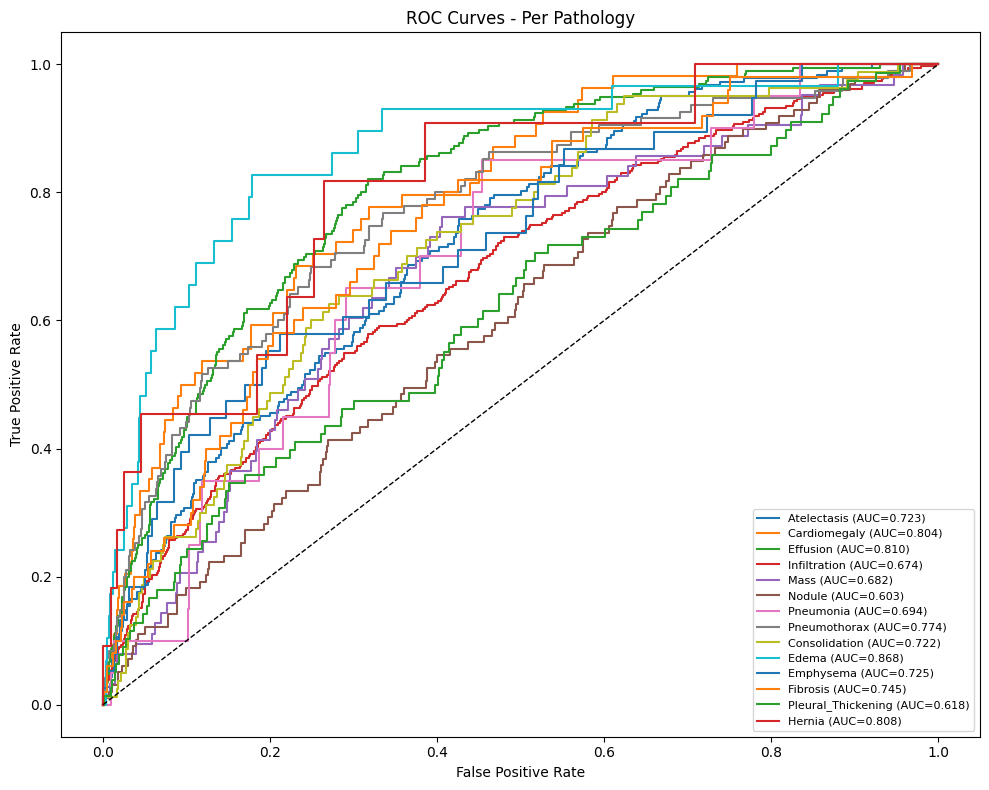

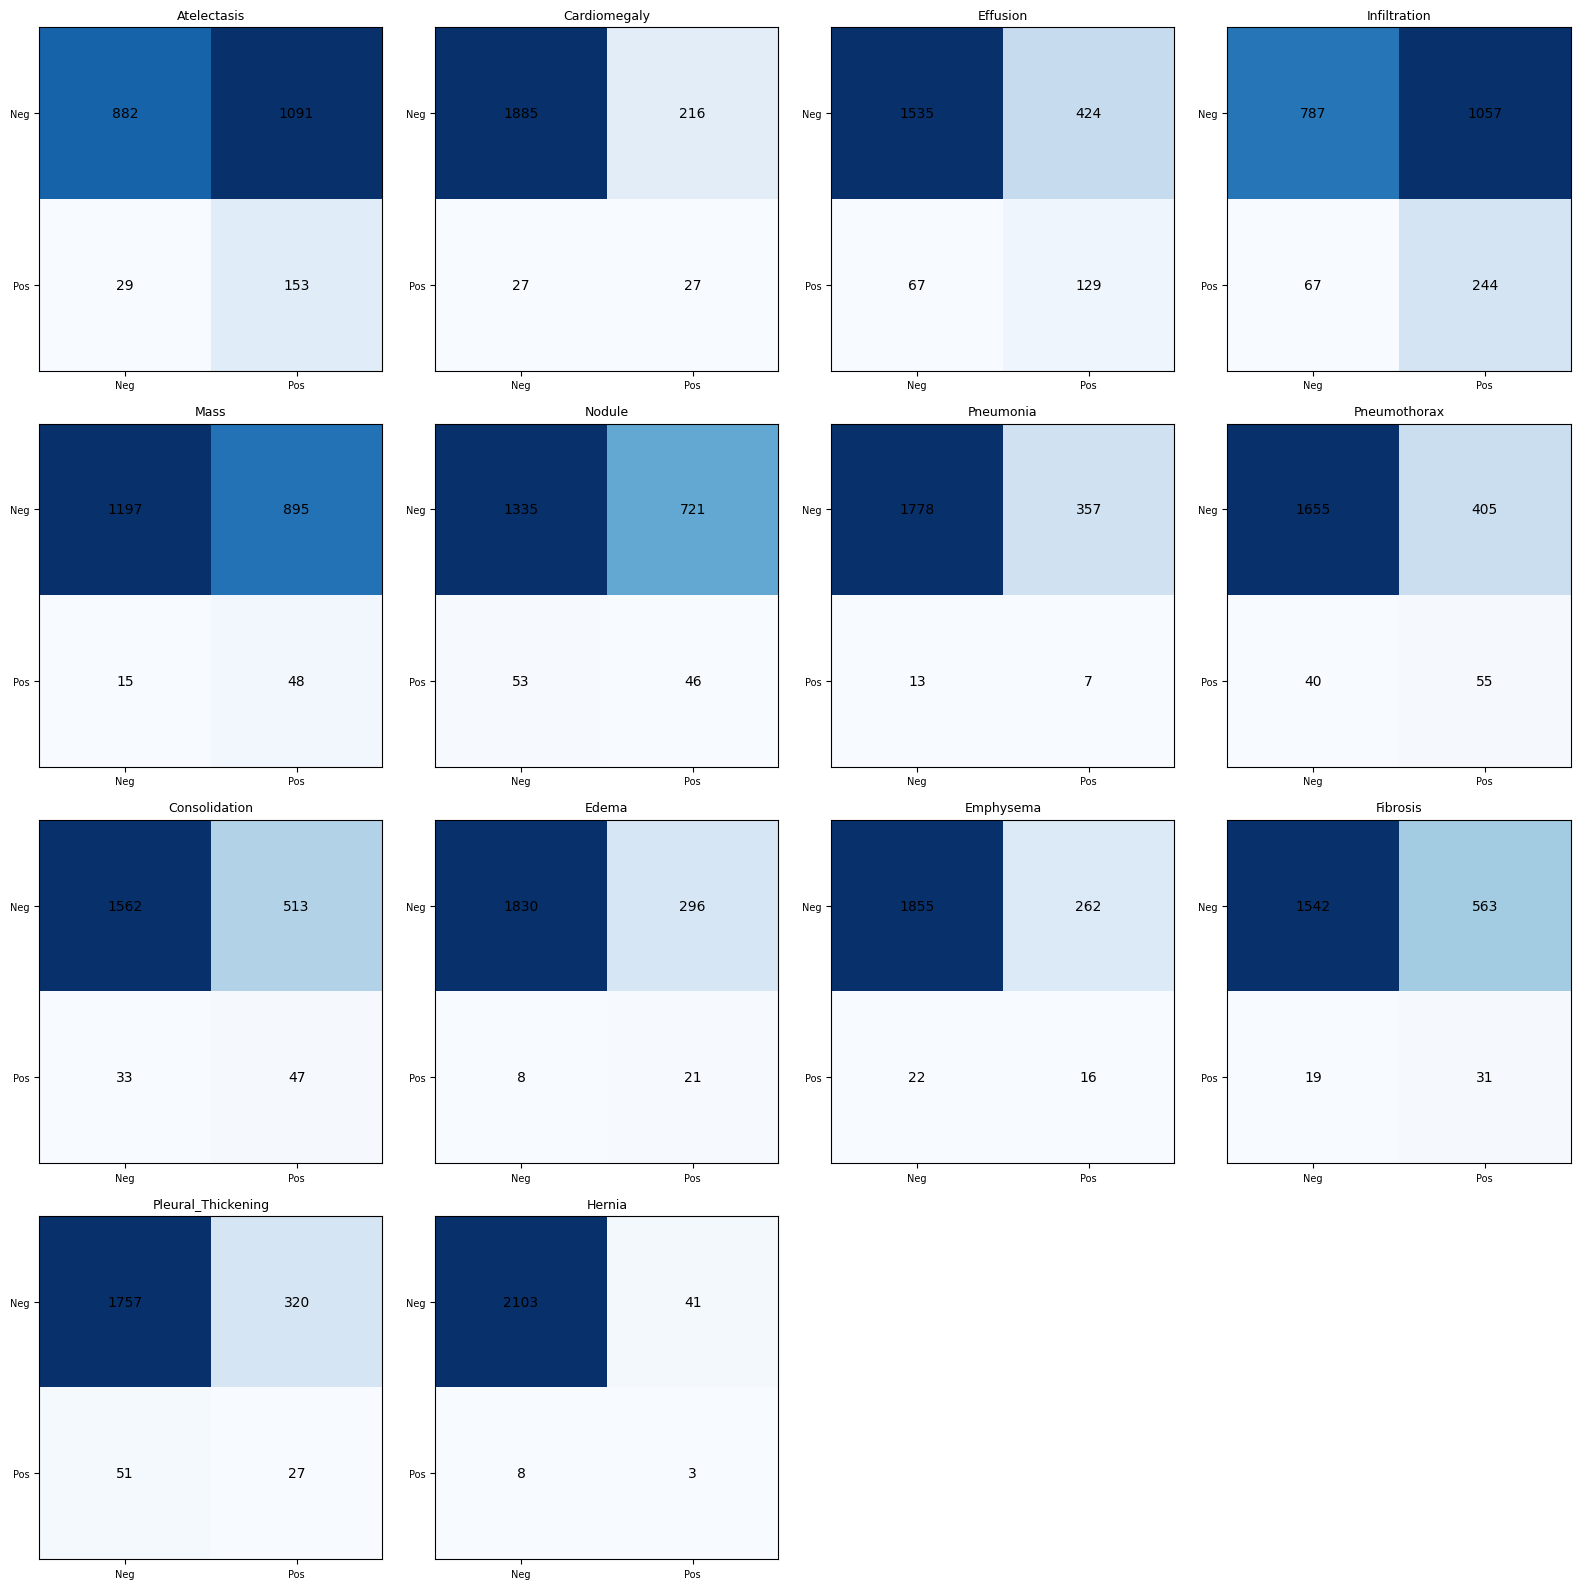


Evaluation complete.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.append(labels.numpy())
    y_pred_probs.append(preds)

y_true = np.concatenate(y_true, axis=0)
y_pred_probs = np.concatenate(y_pred_probs, axis=0)
y_pred_binary = (y_pred_probs >= 0.5).astype(int)

auc_per_class = {}
for i, name in enumerate(PATHOLOGY_NAMES):
    try:
        auc_per_class[name] = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
    except ValueError:
        auc_per_class[name] = float("nan")

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred_binary, average=None, zero_division=0
)

metrics_df = pd.DataFrame({
    "pathology": PATHOLOGY_NAMES,
    "auc": [auc_per_class[n] for n in PATHOLOGY_NAMES],
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})
metrics_df = metrics_df.sort_values("auc", ascending=False).reset_index(drop=True)
print(metrics_df.to_string(index=False))


macro_auc = np.nanmean(list(auc_per_class.values()))
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred_binary, average="macro", zero_division=0
)
print(f"\nMacro AUC:       {macro_auc:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

plt.figure(figsize=(10, 8))
for i, name in enumerate(PATHOLOGY_NAMES):
    if y_true[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_per_class[name]:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Per Pathology")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()
for i, name in enumerate(PATHOLOGY_NAMES):
    cm = confusion_matrix(y_true[:, i], y_pred_binary[:, i])
    ax = axes[i]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=9)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Neg", "Pos"], fontsize=7)
    ax.set_yticklabels(["Neg", "Pos"], fontsize=7)

for j in range(len(PATHOLOGY_NAMES), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print("\nEvaluation complete.")

In [ ]:
from dataclasses import dataclass
from typing import List

@dataclass
class ChestDetectionResult:
    top_finding: str
    findings: List[str]
    pathology_probs: List[float]
    uncertainty: float
    review_flag: bool


In [ ]:
UNCERTAINTY_THRESHOLD = 0.15

def run_chest_pipeline_inference(image, model, pathology_names):
    mean_pred, uncertainty, _ = predict_with_uncertainty(model, image[np.newaxis])
    pathology_probs = mean_pred[0]

    positive_idx = np.where(pathology_probs >= 0.5)[0]
    findings = [pathology_names[i] for i in positive_idx] or ["No Finding"]
    top_finding = pathology_names[int(np.argmax(pathology_probs))]

    review = bool(uncertainty.max() > UNCERTAINTY_THRESHOLD)

    return ChestDetectionResult(
        top_finding=top_finding,
        findings=findings,
        pathology_probs=pathology_probs.tolist(),
        uncertainty=float(uncertainty.max()),
        review_flag=review,
    )


Second Model: EfficientNetB3 (Transfer Learning + Fine-Tuning)

In [14]:
def weighted_bce(pos_weights):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss = -(pos_weights * y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)
    return loss_fn

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, Model
from pathlib import Path


def build_chest_model_effnet(num_pathologies):
    base = EfficientNetB3(input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet")
    base.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.4, name="head_dropout")(x)
    outputs = layers.Dense(num_pathologies, activation="sigmoid", name="output_dense")(x)

    model = Model(inputs, outputs)
    return model, base


effnet_model, effnet_base = build_chest_model_effnet(num_pathologies=len(PATHOLOGY_NAMES))
effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=weighted_bce(POS_WEIGHTS),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name="auc")],
)

EFFNET_SAVE_PATH = Path("experiments/chest_efficientnetb3/best_model.keras")
EFFNET_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Phase 1: training classification head (backbone frozen)")
history_effnet_phase1 = effnet_model.fit(
    train_ds, validation_data=val_ds, epochs=6,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)],
)

effnet_base.trainable = True
FINE_TUNE_AT = max(len(effnet_base.layers) - 40, 0)
for layer in effnet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=weighted_bce(POS_WEIGHTS),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name="auc")],
)

print("Phase 2: fine-tuning top backbone layers")
history_effnet_phase2 = effnet_model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2),
        tf.keras.callbacks.ModelCheckpoint(str(EFFNET_SAVE_PATH), monitor="val_auc", mode="max", save_best_only=True),
    ],
)

if not EFFNET_SAVE_PATH.exists():
    effnet_model.save(EFFNET_SAVE_PATH)
print(f"EfficientNetB3 model saved to: {EFFNET_SAVE_PATH}")


Phase 1: training classification head (backbone frozen)
Epoch 1/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 160s 263ms/step - auc: 0.5282 - loss: 1.2382 - val_auc: 0.5979 - val_loss: 1.2393
Epoch 2/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - auc: 0.5517 - loss: 1.2275 - val_auc: 0.6125 - val_loss: 1.2167
Epoch 3/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 27s 85ms/step - auc: 0.5600 - loss: 1.2213 - val_auc: 0.6173 - val_loss: 1.2206
Epoch 4/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 27s 86ms/step - auc: 0.5735 - loss: 1.2157 - val_auc: 0.6247 - val_loss: 1.2087
Epoch 5/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - auc: 0.5749 - loss: 1.2120 - val_auc: 0.6268 - val_loss: 1.2100
Epoch 6/6
315/315 ━━━━━━━━━━━━━━━━━━━━ 27s 84ms/step - auc: 0.5833 - loss: 1.2141 - val_auc: 0.6249 - val_loss: 1.2219
Phase 2: fine-tuning top backbone layers
Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 139s 276ms/step - auc: 0.5714 - loss: 1.2431 - val_auc: 0.6203 - val_loss: 1.2070 - learning_rate: 1.0000e-05
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━

Threshold Optimization

In [17]:
import tensorflow as tf
from pathlib import Path

MODEL_PATH = Path("experiments/chest_mobilenetv2/best_model.keras")
if not MODEL_PATH.exists():
    alt = MODEL_PATH.with_suffix(".h5")
    MODEL_PATH = alt if alt.exists() else MODEL_PATH

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"Loaded model from: {MODEL_PATH}")

Loaded model from: experiments/chest_mobilenetv2/best_model.keras


In [18]:
import json
from pathlib import Path

import numpy as np
from sklearn.metrics import f1_score


def find_optimal_thresholds(model, val_ds, pathology_names, candidate_thresholds=None):
    if candidate_thresholds is None:
        candidate_thresholds = np.arange(0.05, 0.95, 0.02)

    y_true, y_probs = [], []
    for images, labels in val_ds:
        y_probs.append(model.predict(images, verbose=0))
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true, axis=0)
    y_probs = np.concatenate(y_probs, axis=0)

    best_thresholds = {}
    for i, name in enumerate(pathology_names):
        best_f1, best_t = 0.0, 0.5
        for t in candidate_thresholds:
            f1 = f1_score(y_true[:, i], (y_probs[:, i] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, float(t)
        best_thresholds[name] = best_t
    return best_thresholds


def save_thresholds(thresholds, out_path):
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(thresholds, f, indent=2)
    print(f"Thresholds saved to: {out_path}")


mobilenet_thresholds = find_optimal_thresholds(model, val_ds, PATHOLOGY_NAMES)
save_thresholds(mobilenet_thresholds, "experiments/chest_mobilenetv2/thresholds.json")

effnet_thresholds = find_optimal_thresholds(effnet_model, val_ds, PATHOLOGY_NAMES)
save_thresholds(effnet_thresholds, "experiments/chest_efficientnetb3/thresholds.json")

print("\nMobileNetV2 thresholds:", mobilenet_thresholds)
print("\nEfficientNetB3 thresholds:", effnet_thresholds)


Thresholds saved to: experiments/chest_mobilenetv2/thresholds.json
Thresholds saved to: experiments/chest_efficientnetb3/thresholds.json

MobileNetV2 thresholds: {'Atelectasis': 0.7300000000000002, 'Cardiomegaly': 0.7700000000000002, 'Effusion': 0.6100000000000001, 'Infiltration': 0.6900000000000002, 'Mass': 0.8300000000000002, 'Nodule': 0.6300000000000001, 'Pneumonia': 0.8700000000000002, 'Pneumothorax': 0.6900000000000002, 'Consolidation': 0.7700000000000002, 'Edema': 0.7900000000000001, 'Emphysema': 0.7900000000000001, 'Fibrosis': 0.7700000000000002, 'Pleural_Thickening': 0.6500000000000001, 'Hernia': 0.5700000000000002}

EfficientNetB3 thresholds: {'Atelectasis': 0.5700000000000002, 'Cardiomegaly': 0.6900000000000002, 'Effusion': 0.5500000000000002, 'Infiltration': 0.5500000000000002, 'Mass': 0.6300000000000001, 'Nodule': 0.5100000000000001, 'Pneumonia': 0.7100000000000002, 'Pneumothorax': 0.5100000000000001, 'Consolidation': 0.5900000000000002, 'Edema': 0.8300000000000002, 'Emphys

Model Comparison

In [10]:
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score


def evaluate_model(model, test_ds, pathology_names, thresholds=None):
    if thresholds is None:
        thresholds = {name: 0.5 for name in pathology_names}

    y_true, y_probs = [], []
    for images, labels in test_ds:
        y_probs.append(model.predict(images, verbose=0))
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true, axis=0)
    y_probs = np.concatenate(y_probs, axis=0)

    thresh_vec = np.array([thresholds[name] for name in pathology_names])
    y_pred = (y_probs >= thresh_vec).astype(int)

    auc_per_class = {}
    for i, name in enumerate(pathology_names):
        try:
            auc_per_class[name] = roc_auc_score(y_true[:, i], y_probs[:, i])
        except ValueError:
            auc_per_class[name] = float("nan")

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    per_class_df = pd.DataFrame({
        "pathology": pathology_names,
        "auc": [auc_per_class[n] for n in pathology_names],
        "threshold": [thresholds[n] for n in pathology_names],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    }).sort_values("auc", ascending=False).reset_index(drop=True)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="micro", zero_division=0
    )
    macro_auc = float(np.nanmean(list(auc_per_class.values())))

    summary = {
        "macro_auc": macro_auc,
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
    }
    return per_class_df, summary, y_true, y_probs


def save_evaluation(model_name, out_dir, per_class_df, summary, y_true, y_probs):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    per_class_df.to_csv(out_dir / "eval_per_class.csv", index=False)
    with open(out_dir / "eval_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    np.save(out_dir / "y_true.npy", y_true)
    np.save(out_dir / "y_probs.npy", y_probs)
    print(f"[{model_name}] Macro AUC={summary['macro_auc']:.4f}  "
          f"Macro F1={summary['macro_f1']:.4f}  "
          f"Macro Precision={summary['macro_precision']:.4f}  "
          f"Macro Recall={summary['macro_recall']:.4f}")


# --- MobileNetV2: evaluate, save, then free memory before the next model ---
mobilenet_per_class, mobilenet_summary, mobilenet_y_true, mobilenet_y_probs = evaluate_model(
    model, test_ds, PATHOLOGY_NAMES, mobilenet_thresholds
)
save_evaluation("MobileNetV2", "experiments/chest_mobilenetv2",
                 mobilenet_per_class, mobilenet_summary, mobilenet_y_true, mobilenet_y_probs)

del mobilenet_y_true, mobilenet_y_probs
gc.collect()

# --- EfficientNetB3 ---
effnet_per_class, effnet_summary, effnet_y_true, effnet_y_probs = evaluate_model(
    effnet_model, test_ds, PATHOLOGY_NAMES, effnet_thresholds
)
save_evaluation("EfficientNetB3", "experiments/chest_efficientnetb3",
                 effnet_per_class, effnet_summary, effnet_y_true, effnet_y_probs)

print("\n--- MobileNetV2 per-pathology metrics ---")
print(mobilenet_per_class.to_string(index=False))
print("\n--- EfficientNetB3 per-pathology metrics ---")
print(effnet_per_class.to_string(index=False))

[MobileNetV2] Macro AUC=0.7321  Macro F1=0.1633  Macro Precision=0.1274  Macro Recall=0.2544
[EfficientNetB3] Macro AUC=0.6421  Macro F1=0.1088  Macro Precision=0.0977  Macro Recall=0.2391

--- MobileNetV2 per-pathology metrics ---
         pathology      auc  threshold  precision   recall       f1  support
             Edema 0.867859       0.79   0.126126 0.482759 0.200000       29
          Effusion 0.810263       0.61   0.283668 0.505102 0.363303      196
            Hernia 0.807921       0.57   0.071429 0.181818 0.102564       11
      Cardiomegaly 0.803542       0.77   0.181818 0.148148 0.163265       54
      Pneumothorax 0.773510       0.69   0.200000 0.347368 0.253846       95
          Fibrosis 0.745083       0.77   0.078431 0.240000 0.118227       50
         Emphysema 0.724772       0.79   0.081081 0.078947 0.080000       38
       Atelectasis 0.722771       0.73   0.163636 0.494505 0.245902      182
     Consolidation 0.721904       0.77   0.126126 0.175000 0.146597       8

         model  macro_auc  macro_precision  macro_recall  macro_f1  micro_precision  micro_recall  micro_f1
   MobileNetV2   0.732077         0.127367      0.254450  0.163301         0.171127      0.347626  0.229351
EfficientNetB3   0.642099         0.097717      0.239108  0.108824         0.114014      0.367534  0.174039


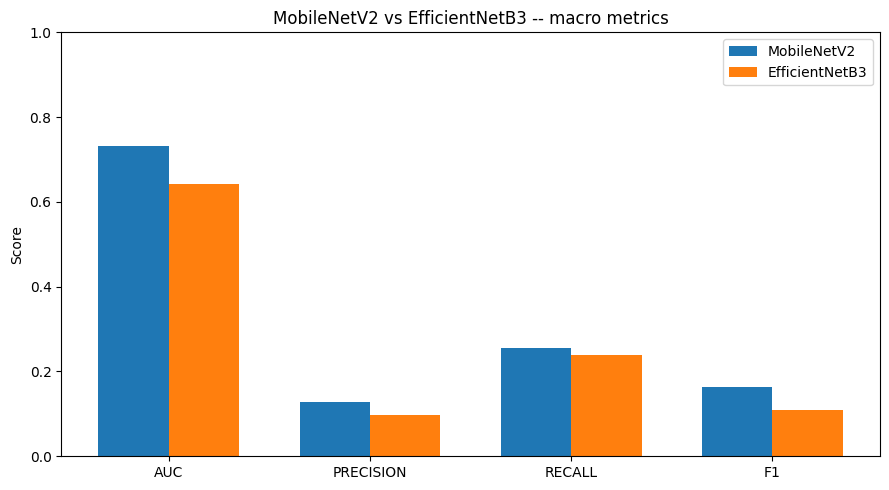

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

comparison_df = pd.DataFrame([
    {"model": "MobileNetV2", **mobilenet_summary},
    {"model": "EfficientNetB3", **effnet_summary},
])
comparison_df.to_csv("experiments/model_comparison.csv", index=False)
print(comparison_df.to_string(index=False))

metrics_to_plot = ["macro_auc", "macro_precision", "macro_recall", "macro_f1"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for i, row in comparison_df.iterrows():
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=row["model"])

ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.replace("macro_", "").upper() for m in metrics_to_plot])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("MobileNetV2 vs EfficientNetB3 -- macro metrics")
ax.legend()
plt.tight_layout()
Path("assets/eda").mkdir(parents=True, exist_ok=True)
plt.savefig("assets/eda/model_comparison.png")
plt.show()
plt.close()


Grad-CAM Explainability

/tmp/ipykernel_76951/260507487.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


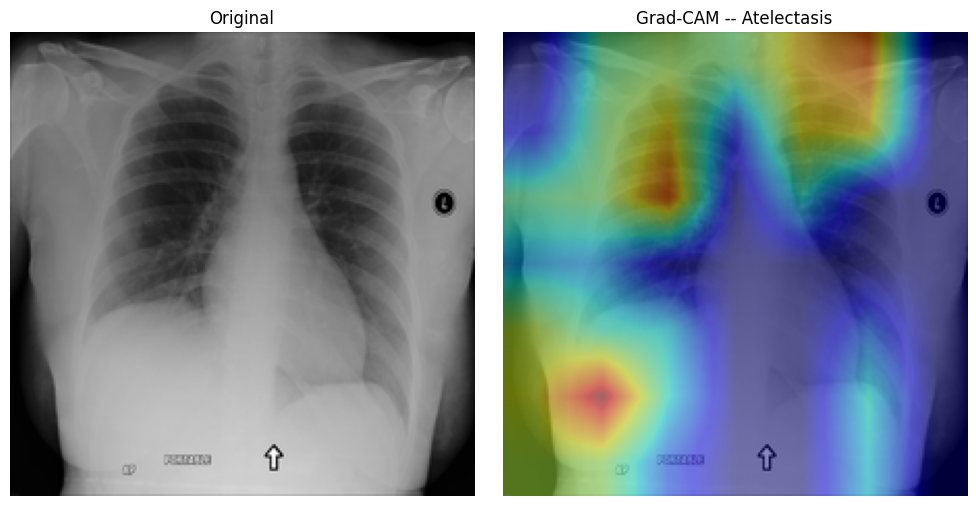

In [12]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image


def make_gradcam_heatmap(img_array, model, pred_index=None):
    base = model.get_layer(index=1)
    last_conv_layer = base.layers[-1]
    conv_model = tf.keras.Model(base.input, last_conv_layer.output)

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = model.get_layer("gap")(classifier_input)
    x = model.get_layer("output_dense")(x)
    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_output = conv_model(img_array)
        tape.watch(conv_output)
        preds = classifier_model(conv_output)
        if pred_index is None:
            pred_index = int(tf.argmax(preds[0]))
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_index


def overlay_gradcam(orig_img_pil, heatmap, alpha=0.45):
    orig_rgb = orig_img_pil.convert("RGB")
    heatmap_img = Image.fromarray(np.uint8(255 * heatmap)).resize(orig_rgb.size, Image.BILINEAR)
    heatmap_resized = np.asarray(heatmap_img, dtype=np.float32) / 255.0
    jet = cm.get_cmap("jet")
    colored = jet(heatmap_resized)[:, :, :3]
    colored_img = Image.fromarray(np.uint8(colored * 255)).convert("RGB")
    return Image.blend(orig_rgb, colored_img, alpha=alpha)



sample_batch = next(iter(test_ds.take(1)))
sample_images, sample_labels = sample_batch
sample_img_array = sample_images[0:1]

heatmap, pred_idx = make_gradcam_heatmap(sample_img_array, model)
denorm = (sample_images[0].numpy() * CHANNEL_STD.numpy() + CHANNEL_MEAN.numpy())
denorm_img = Image.fromarray(np.uint8(np.clip(denorm, 0, 1) * 255))
overlay = overlay_gradcam(denorm_img, heatmap)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(denorm_img)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Grad-CAM -- {PATHOLOGY_NAMES[pred_idx]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()


Folder Structure

In [13]:
from pathlib import Path

root = Path("chest_xray_platform")
folders = [
    "data/raw/nih_chestxray14",
    "dataset/train", "dataset/val", "dataset/test",
    "experiments/chest_efficientnetb3",
    "dashboard/pages",
]
for f in folders:
    (root / f).mkdir(parents=True, exist_ok=True)


Streamlit

In [14]:
# Writes the multi-page Streamlit dashboard to disk (utils.py + 3 pages).
# File contents are base64-encoded here purely so the notebook JSON
# never has to worry about escaping quotes/newlines in the source code below.
import base64
from pathlib import Path

_DASHBOARD_FILES_B64 = {
    'dashboard/utils.py': (
        'IiIiU2hhcmVkIGNvbnN0YW50cyBhbmQgaGVscGVycyBmb3IgdGhlIENoZXN0IFgtUmF5IERpYWdub3N0aWMgUGxhdGZvcm0gZGFz'
        'aGJvYXJkLgoKSW1wb3J0ZWQgYnkgSG9tZS5weSBhbmQgZXZlcnkgcGFnZSB1bmRlciBwYWdlcy8gc28gdGhlIHByZXByb2Nlc3Np'
        'bmcsCm1vZGVsLWxvYWRpbmcsIGFuZCBpbmZlcmVuY2UgbG9naWMgb25seSBsaXZlcyBpbiBvbmUgcGxhY2UuCiIiIgppbXBvcnQg'
        'anNvbgpmcm9tIGRhdGFjbGFzc2VzIGltcG9ydCBkYXRhY2xhc3MKZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCmZyb20gdHlwaW5n'
        'IGltcG9ydCBEaWN0LCBMaXN0LCBPcHRpb25hbCwgVHVwbGUKCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgc3RyZWFtbGl0IGFz'
        'IHN0CmltcG9ydCB0ZW5zb3JmbG93IGFzIHRmCmZyb20gUElMIGltcG9ydCBJbWFnZQoKSU1HX1NJWkUgPSAoMjI0LCAyMjQpClBB'
        'VEhPTE9HWV9OQU1FUyA9IFsKICAgICJBdGVsZWN0YXNpcyIsICJDYXJkaW9tZWdhbHkiLCAiRWZmdXNpb24iLCAiSW5maWx0cmF0'
        'aW9uIiwgIk1hc3MiLAogICAgIk5vZHVsZSIsICJQbmV1bW9uaWEiLCAiUG5ldW1vdGhvcmF4IiwgIkNvbnNvbGlkYXRpb24iLCAi'
        'RWRlbWEiLAogICAgIkVtcGh5c2VtYSIsICJGaWJyb3NpcyIsICJQbGV1cmFsX1RoaWNrZW5pbmciLCAiSGVybmlhIiwKXQpTVEFU'
        'U19QQVRIID0gImRhdGFzZXQvc3RhdHMuanNvbiIKVU5DRVJUQUlOVFlfVEhSRVNIT0xEID0gMC4xNQoKTU9ERUxfSU5GTyA9IHsK'
        'ICAgICJNb2JpbGVOZXRWMiI6IHsKICAgICAgICAibW9kZWxfcGF0aCI6ICJleHBlcmltZW50cy9jaGVzdF9tb2JpbGVuZXR2Mi9i'
        'ZXN0X21vZGVsLmtlcmFzIiwKICAgICAgICAidGhyZXNob2xkc19wYXRoIjogImV4cGVyaW1lbnRzL2NoZXN0X21vYmlsZW5ldHYy'
        'L3RocmVzaG9sZHMuanNvbiIsCiAgICAgICAgImV2YWxfc3VtbWFyeV9wYXRoIjogImV4cGVyaW1lbnRzL2NoZXN0X21vYmlsZW5l'
        'dHYyL2V2YWxfc3VtbWFyeS5qc29uIiwKICAgICAgICAiZXZhbF9wZXJfY2xhc3NfcGF0aCI6ICJleHBlcmltZW50cy9jaGVzdF9t'
        'b2JpbGVuZXR2Mi9ldmFsX3Blcl9jbGFzcy5jc3YiLAogICAgfSwKICAgICJFZmZpY2llbnROZXRCMyI6IHsKICAgICAgICAibW9k'
        'ZWxfcGF0aCI6ICJleHBlcmltZW50cy9jaGVzdF9lZmZpY2llbnRuZXRiMy9iZXN0X21vZGVsLmtlcmFzIiwKICAgICAgICAidGhy'
        'ZXNob2xkc19wYXRoIjogImV4cGVyaW1lbnRzL2NoZXN0X2VmZmljaWVudG5ldGIzL3RocmVzaG9sZHMuanNvbiIsCiAgICAgICAg'
        'ImV2YWxfc3VtbWFyeV9wYXRoIjogImV4cGVyaW1lbnRzL2NoZXN0X2VmZmljaWVudG5ldGIzL2V2YWxfc3VtbWFyeS5qc29uIiwK'
        'ICAgICAgICAiZXZhbF9wZXJfY2xhc3NfcGF0aCI6ICJleHBlcmltZW50cy9jaGVzdF9lZmZpY2llbnRuZXRiMy9ldmFsX3Blcl9j'
        'bGFzcy5jc3YiLAogICAgfSwKfQoKCkBkYXRhY2xhc3MKY2xhc3MgQ2hlc3REZXRlY3Rpb25SZXN1bHQ6CiAgICB0b3BfZmluZGlu'
        'Zzogc3RyCiAgICBmaW5kaW5nczogTGlzdFtzdHJdCiAgICBwYXRob2xvZ3lfcHJvYnM6IExpc3RbZmxvYXRdCiAgICB0aHJlc2hv'
        'bGRzX3VzZWQ6IExpc3RbZmxvYXRdCiAgICB1bmNlcnRhaW50eTogTGlzdFtmbG9hdF0KICAgIHJldmlld19mbGFnOiBib29sCgoK'
        'ZGVmIHN0ZXAyX3Jlc2l6ZV9sZXR0ZXJib3goaW1nOiBJbWFnZS5JbWFnZSwgc2l6ZT1JTUdfU0laRSkgLT4gSW1hZ2UuSW1hZ2U6'
        'CiAgICBpbWcgPSBpbWcuY29weSgpCiAgICBpbWcudGh1bWJuYWlsKHNpemUsIEltYWdlLkxBTkNaT1MpCiAgICBiYWNrZ3JvdW5k'
        'ID0gSW1hZ2UubmV3KCJSR0IiLCBzaXplLCAoMCwgMCwgMCkpCiAgICBvZmZzZXQgPSAoKHNpemVbMF0gLSBpbWcud2lkdGgpIC8v'
        'IDIsIChzaXplWzFdIC0gaW1nLmhlaWdodCkgLy8gMikKICAgIGJhY2tncm91bmQucGFzdGUoaW1nLCBvZmZzZXQpCiAgICByZXR1'
        'cm4gYmFja2dyb3VuZAoKCkBzdC5jYWNoZV9yZXNvdXJjZQpkZWYgbG9hZF9zdGF0cygpIC0+IFR1cGxlW25wLm5kYXJyYXksIG5w'
        'Lm5kYXJyYXldOgogICAgd2l0aCBvcGVuKFNUQVRTX1BBVEgpIGFzIGY6CiAgICAgICAgc3RhdHMgPSBqc29uLmxvYWQoZikKICAg'
        'IHJldHVybiAoCiAgICAgICAgbnAuYXJyYXkoc3RhdHNbIm1lYW4iXSwgZHR5cGU9bnAuZmxvYXQzMiksCiAgICAgICAgbnAuYXJy'
        'YXkoc3RhdHNbInN0ZCJdLCBkdHlwZT1ucC5mbG9hdDMyKSwKICAgICkKCgpkZWYgcHJlcHJvY2Vzc191cGxvYWQodXBsb2FkZWRf'
        'ZmlsZSkgLT4gbnAubmRhcnJheToKICAgIG1lYW4sIHN0ZCA9IGxvYWRfc3RhdHMoKQogICAgaW1nID0gSW1hZ2Uub3Blbih1cGxv'
        'YWRlZF9maWxlKS5jb252ZXJ0KCJSR0IiKQogICAgaW1nID0gc3RlcDJfcmVzaXplX2xldHRlcmJveChpbWcpCiAgICBhcnIgPSBu'
        'cC5hc2FycmF5KGltZywgZHR5cGU9bnAuZmxvYXQzMikgLyAyNTUuMAogICAgYXJyID0gKGFyciAtIG1lYW4pIC8gc3RkCiAgICBy'
        'ZXR1cm4gYXJyCgoKQHN0LmNhY2hlX3Jlc291cmNlCmRlZiBsb2FkX21vZGVscygpIC0+IERpY3Rbc3RyLCB0Zi5rZXJhcy5Nb2Rl'
        'bF06CiAgICAiIiJMb2FkcyB3aGljaGV2ZXIgdHJhaW5lZCBtb2RlbHMgYXJlIGF2YWlsYWJsZSBvbiBkaXNrLiBNaXNzaW5nIG1v'
        'ZGVscwogICAgYXJlIHNraXBwZWQgKG5vdCBhbiBlcnJvcikgc28gdGhlIGFwcCBzdGlsbCB3b3JrcyBpZiBvbmx5IG9uZSBoYXMg'
        'YmVlbgogICAgdHJhaW5lZCB5ZXQuIiIiCiAgICBtb2RlbHMgPSB7fQogICAgZm9yIG5hbWUsIGluZm8gaW4gTU9ERUxfSU5GTy5p'
        'dGVtcygpOgogICAgICAgIHBhdGggPSBQYXRoKGluZm9bIm1vZGVsX3BhdGgiXSkKICAgICAgICBpZiBwYXRoLmV4aXN0cygpOgog'
        'ICAgICAgICAgICBtb2RlbHNbbmFtZV0gPSB0Zi5rZXJhcy5tb2RlbHMubG9hZF9tb2RlbChwYXRoLCBjb21waWxlPUZhbHNlKQog'
        'ICAgcmV0dXJuIG1vZGVscwoKCkBzdC5jYWNoZV9kYXRhCmRlZiBsb2FkX3RocmVzaG9sZHMobW9kZWxfbmFtZTogc3RyKSAtPiBE'
        'aWN0W3N0ciwgZmxvYXRdOgogICAgcGF0aCA9IFBhdGgoTU9ERUxfSU5GT1ttb2RlbF9uYW1lXVsidGhyZXNob2xkc19wYXRoIl0p'
        'CiAgICBpZiBub3QgcGF0aC5leGlzdHMoKToKICAgICAgICByZXR1cm4ge25hbWU6IDAuNSBmb3IgbmFtZSBpbiBQQVRIT0xPR1lf'
        'TkFNRVN9CiAgICB3aXRoIG9wZW4ocGF0aCkgYXMgZjoKICAgICAgICByZXR1cm4ganNvbi5sb2FkKGYpCgoKZGVmIGF2YWlsYWJs'
        'ZV9tb2RlbHMoKSAtPiBMaXN0W3N0cl06CiAgICByZXR1cm4gW25hbWUgZm9yIG5hbWUsIGluZm8gaW4gTU9ERUxfSU5GTy5pdGVt'
        'cygpIGlmIFBhdGgoaW5mb1sibW9kZWxfcGF0aCJdKS5leGlzdHMoKV0KCgpkZWYgcHJlZGljdF93aXRoX3VuY2VydGFpbnR5KG1v'
        'ZGVsLCBpbWFnZV9iYXRjaCwgbl9pdGVyOiBpbnQgPSAyMCk6CiAgICAiIiJTZXZlcmFsIHN0b2NoYXN0aWMgZm9yd2FyZCBwYXNz'
        'ZXMgd2l0aCBkcm9wb3V0IGtlcHQgYWN0aXZlCiAgICAodHJhaW5pbmc9VHJ1ZSkgZ2l2ZSBhIG1lYW4gcHJlZGljdGlvbiBwbHVz'
        'IGEgcGVyLWNsYXNzIHVuY2VydGFpbnR5CiAgICAoc3RkIGFjcm9zcyBwYXNzZXMpIGluc3RlYWQgb2YgYSBzaW5nbGUgcG9pbnQg'
        'ZXN0aW1hdGUuIiIiCiAgICBwcmVkcyA9IG5wLnN0YWNrKFttb2RlbChpbWFnZV9iYXRjaCwgdHJhaW5pbmc9VHJ1ZSkubnVtcHko'
        'KSBmb3IgXyBpbiByYW5nZShuX2l0ZXIpXSkKICAgIG1lYW5fcHJlZCA9IHByZWRzLm1lYW4oYXhpcz0wKQogICAgdW5jZXJ0YWlu'
        'dHkgPSBwcmVkcy5zdGQoYXhpcz0wKQogICAgcmV0dXJuIG1lYW5fcHJlZCwgdW5jZXJ0YWludHksIHByZWRzCgoKZGVmIHJ1bl9j'
        'aGVzdF9waXBlbGluZV9pbmZlcmVuY2UoaW1hZ2UsIG1vZGVsLCBwYXRob2xvZ3lfbmFtZXMsIHRocmVzaG9sZHM6IE9wdGlvbmFs'
        'W0RpY3Rbc3RyLCBmbG9hdF1dID0gTm9uZSk6CiAgICBpZiB0aHJlc2hvbGRzIGlzIE5vbmU6CiAgICAgICAgdGhyZXNob2xkcyA9'
        'IHtuYW1lOiAwLjUgZm9yIG5hbWUgaW4gcGF0aG9sb2d5X25hbWVzfQogICAgbWVhbl9wcmVkLCB1bmNlcnRhaW50eSwgXyA9IHBy'
        'ZWRpY3Rfd2l0aF91bmNlcnRhaW50eShtb2RlbCwgaW1hZ2VbbnAubmV3YXhpc10pCiAgICBwYXRob2xvZ3lfcHJvYnMgPSBtZWFu'
        'X3ByZWRbMF0KICAgIHRocmVzaF92ZWMgPSBucC5hcnJheShbdGhyZXNob2xkc1tuYW1lXSBmb3IgbmFtZSBpbiBwYXRob2xvZ3lf'
        'bmFtZXNdKQoKICAgIHBvc2l0aXZlX2lkeCA9IG5wLndoZXJlKHBhdGhvbG9neV9wcm9icyA+PSB0aHJlc2hfdmVjKVswXQogICAg'
        'ZmluZGluZ3MgPSBbcGF0aG9sb2d5X25hbWVzW2ldIGZvciBpIGluIHBvc2l0aXZlX2lkeF0gb3IgWyJObyBGaW5kaW5nIl0KICAg'
        'IHRvcF9maW5kaW5nID0gcGF0aG9sb2d5X25hbWVzW2ludChucC5hcmdtYXgocGF0aG9sb2d5X3Byb2JzKSldCgogICAgcmV2aWV3'
        'ID0gYm9vbCh1bmNlcnRhaW50eS5tYXgoKSA+IFVOQ0VSVEFJTlRZX1RIUkVTSE9MRCkKCiAgICByZXR1cm4gQ2hlc3REZXRlY3Rp'
        'b25SZXN1bHQoCiAgICAgICAgdG9wX2ZpbmRpbmc9dG9wX2ZpbmRpbmcsCiAgICAgICAgZmluZGluZ3M9ZmluZGluZ3MsCiAgICAg'
        'ICAgcGF0aG9sb2d5X3Byb2JzPXBhdGhvbG9neV9wcm9icy50b2xpc3QoKSwKICAgICAgICB0aHJlc2hvbGRzX3VzZWQ9dGhyZXNo'
        'X3ZlYy50b2xpc3QoKSwKICAgICAgICB1bmNlcnRhaW50eT11bmNlcnRhaW50eVswXS50b2xpc3QoKSwKICAgICAgICByZXZpZXdf'
        'ZmxhZz1yZXZpZXcsCiAgICApCgoKZGVmIG1ha2VfZ3JhZGNhbV9oZWF0bWFwKGltZ19hcnJheSwgbW9kZWwsIHByZWRfaW5kZXg6'
        'IE9wdGlvbmFsW2ludF0gPSBOb25lKToKICAgICIiIkdyYWQtQ0FNIGZvciB0aGUgYmFzZShpbnB1dCkgLT4gZ2FwIC0+IGRyb3Bv'
        'dXQgLT4gb3V0cHV0X2RlbnNlIGhlYWQKICAgIHNoYXJlZCBieSBib3RoIGJhY2tib25lcyBpbiB0aGlzIHByb2plY3QuIFNwbGl0'
        'cyB0aGUgbW9kZWwgaW50byBhCiAgICBjb252X21vZGVsIChpbnB1dCAtPiBsYXN0IGNvbnYgZmVhdHVyZSBtYXAgb2YgdGhlIGJh'
        'Y2tib25lKSBhbmQgYQogICAgY2xhc3NpZmllcl9tb2RlbCAodGhhdCBmZWF0dXJlIG1hcCAtPiBwcmVkaWN0aW9uKSwgdGhlbiBk'
        'aWZmZXJlbnRpYXRlcwogICAgdGhlIHRhcmdldCBjbGFzcyBzY29yZSB3aXRoIHJlc3BlY3QgdG8gdGhlIGNvbnYgZmVhdHVyZXMu'
        'IiIiCiAgICBiYXNlID0gbW9kZWwuZ2V0X2xheWVyKGluZGV4PTEpCiAgICBsYXN0X2NvbnZfbGF5ZXIgPSBiYXNlLmxheWVyc1st'
        'MV0KICAgIGNvbnZfbW9kZWwgPSB0Zi5rZXJhcy5Nb2RlbChiYXNlLmlucHV0LCBsYXN0X2NvbnZfbGF5ZXIub3V0cHV0KQoKICAg'
        'IGNsYXNzaWZpZXJfaW5wdXQgPSB0Zi5rZXJhcy5JbnB1dChzaGFwZT1sYXN0X2NvbnZfbGF5ZXIub3V0cHV0LnNoYXBlWzE6XSkK'
        'ICAgIHggPSBtb2RlbC5nZXRfbGF5ZXIoImdhcCIpKGNsYXNzaWZpZXJfaW5wdXQpCiAgICB4ID0gbW9kZWwuZ2V0X2xheWVyKCJv'
        'dXRwdXRfZGVuc2UiKSh4KQogICAgY2xhc3NpZmllcl9tb2RlbCA9IHRmLmtlcmFzLk1vZGVsKGNsYXNzaWZpZXJfaW5wdXQsIHgp'
        'CgogICAgd2l0aCB0Zi5HcmFkaWVudFRhcGUoKSBhcyB0YXBlOgogICAgICAgIGNvbnZfb3V0cHV0ID0gY29udl9tb2RlbChpbWdf'
        'YXJyYXkpCiAgICAgICAgdGFwZS53YXRjaChjb252X291dHB1dCkKICAgICAgICBwcmVkcyA9IGNsYXNzaWZpZXJfbW9kZWwoY29u'
        'dl9vdXRwdXQpCiAgICAgICAgaWYgcHJlZF9pbmRleCBpcyBOb25lOgogICAgICAgICAgICBwcmVkX2luZGV4ID0gaW50KHRmLmFy'
        'Z21heChwcmVkc1swXSkpCiAgICAgICAgY2xhc3NfY2hhbm5lbCA9IHByZWRzWzosIHByZWRfaW5kZXhdCgogICAgZ3JhZHMgPSB0'
        'YXBlLmdyYWRpZW50KGNsYXNzX2NoYW5uZWwsIGNvbnZfb3V0cHV0KQogICAgcG9vbGVkX2dyYWRzID0gdGYucmVkdWNlX21lYW4o'
        'Z3JhZHMsIGF4aXM9KDAsIDEsIDIpKQogICAgY29udl9vdXRwdXQgPSBjb252X291dHB1dFswXQogICAgaGVhdG1hcCA9IGNvbnZf'
        'b3V0cHV0IEAgcG9vbGVkX2dyYWRzWy4uLiwgdGYubmV3YXhpc10KICAgIGhlYXRtYXAgPSB0Zi5zcXVlZXplKGhlYXRtYXApCiAg'
        'ICBoZWF0bWFwID0gdGYubWF4aW11bShoZWF0bWFwLCAwKSAvICh0Zi5tYXRoLnJlZHVjZV9tYXgoaGVhdG1hcCkgKyAxZS04KQog'
        'ICAgcmV0dXJuIGhlYXRtYXAubnVtcHkoKSwgcHJlZF9pbmRleAoKCmRlZiBvdmVybGF5X2dyYWRjYW0ob3JpZ19pbWdfcGlsOiBJ'
        'bWFnZS5JbWFnZSwgaGVhdG1hcDogbnAubmRhcnJheSwgYWxwaGE6IGZsb2F0ID0gMC40NSkgLT4gSW1hZ2UuSW1hZ2U6CiAgICBp'
        'bXBvcnQgbWF0cGxvdGxpYi5jbSBhcyBjbQoKICAgIG9yaWdfcmdiID0gb3JpZ19pbWdfcGlsLmNvbnZlcnQoIlJHQiIpCiAgICBo'
        'ZWF0bWFwX2ltZyA9IEltYWdlLmZyb21hcnJheShucC51aW50OCgyNTUgKiBoZWF0bWFwKSkucmVzaXplKG9yaWdfcmdiLnNpemUs'
        'IEltYWdlLkJJTElORUFSKQogICAgaGVhdG1hcF9yZXNpemVkID0gbnAuYXNhcnJheShoZWF0bWFwX2ltZywgZHR5cGU9bnAuZmxv'
        'YXQzMikgLyAyNTUuMAoKICAgIGpldCA9IGNtLmdldF9jbWFwKCJqZXQiKQogICAgY29sb3JlZCA9IGpldChoZWF0bWFwX3Jlc2l6'
        'ZWQpWzosIDosIDozXQogICAgY29sb3JlZF9pbWcgPSBJbWFnZS5mcm9tYXJyYXkobnAudWludDgoY29sb3JlZCAqIDI1NSkpLmNv'
        'bnZlcnQoIlJHQiIpCiAgICByZXR1cm4gSW1hZ2UuYmxlbmQob3JpZ19yZ2IsIGNvbG9yZWRfaW1nLCBhbHBoYT1hbHBoYSkKCgpA'
        'c3QuY2FjaGVfZGF0YQpkZWYgbG9hZF9ldmFsX3Jlc3VsdHMobW9kZWxfbmFtZTogc3RyKToKICAgICIiIlJldHVybnMgKHN1bW1h'
        'cnlfZGljdCwgcGVyX2NsYXNzX2RhdGFmcmFtZSkgZm9yIGEgdHJhaW5lZCBtb2RlbCwgb3IKICAgIChOb25lLCBOb25lKSBpZiB0'
        'aGF0IG1vZGVsIGhhc24ndCBiZWVuIGV2YWx1YXRlZCB5ZXQuIiIiCiAgICBpbXBvcnQgcGFuZGFzIGFzIHBkCgogICAgaW5mbyA9'
        'IE1PREVMX0lORk9bbW9kZWxfbmFtZV0KICAgIHN1bW1hcnlfcGF0aCA9IFBhdGgoaW5mb1siZXZhbF9zdW1tYXJ5X3BhdGgiXSkK'
        'ICAgIHBlcl9jbGFzc19wYXRoID0gUGF0aChpbmZvWyJldmFsX3Blcl9jbGFzc19wYXRoIl0pCiAgICBpZiBub3Qgc3VtbWFyeV9w'
        'YXRoLmV4aXN0cygpIG9yIG5vdCBwZXJfY2xhc3NfcGF0aC5leGlzdHMoKToKICAgICAgICByZXR1cm4gTm9uZSwgTm9uZQogICAg'
        'd2l0aCBvcGVuKHN1bW1hcnlfcGF0aCkgYXMgZjoKICAgICAgICBzdW1tYXJ5ID0ganNvbi5sb2FkKGYpCiAgICBwZXJfY2xhc3Mg'
        'PSBwZC5yZWFkX2NzdihwZXJfY2xhc3NfcGF0aCkKICAgIHJldHVybiBzdW1tYXJ5LCBwZXJfY2xhc3MKCgpAc3QuY2FjaGVfZGF0'
        'YQpkZWYgbG9hZF9yb2NfYXJyYXlzKG1vZGVsX25hbWU6IHN0cik6CiAgICAiIiJSZXR1cm5zICh5X3RydWUsIHlfcHJvYnMpIHNh'
        'dmVkIGR1cmluZyBldmFsdWF0aW9uLCBvciAoTm9uZSwgTm9uZSkuIiIiCiAgICBpbmZvID0gTU9ERUxfSU5GT1ttb2RlbF9uYW1l'
        'XQogICAgYmFzZV9kaXIgPSBQYXRoKGluZm9bIm1vZGVsX3BhdGgiXSkucGFyZW50CiAgICB5X3RydWVfcGF0aCA9IGJhc2VfZGly'
        'IC8gInlfdHJ1ZS5ucHkiCiAgICB5X3Byb2JzX3BhdGggPSBiYXNlX2RpciAvICJ5X3Byb2JzLm5weSIKICAgIGlmIG5vdCB5X3Ry'
        'dWVfcGF0aC5leGlzdHMoKSBvciBub3QgeV9wcm9ic19wYXRoLmV4aXN0cygpOgogICAgICAgIHJldHVybiBOb25lLCBOb25lCiAg'
        'ICByZXR1cm4gbnAubG9hZCh5X3RydWVfcGF0aCksIG5wLmxvYWQoeV9wcm9ic19wYXRoKQo='
    ),
    'dashboard/Home.py': (
        'aW1wb3J0IHN5cwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKCnN5cy5wYXRoLmFwcGVuZChzdHIoUGF0aChfX2ZpbGVfXykucmVz'
        'b2x2ZSgpLnBhcmVudCkpCgppbXBvcnQgcGFuZGFzIGFzIHBkCmltcG9ydCBzdHJlYW1saXQgYXMgc3QKCmZyb20gdXRpbHMgaW1w'
        'b3J0IFBBVEhPTE9HWV9OQU1FUywgYXZhaWxhYmxlX21vZGVscwoKc3Quc2V0X3BhZ2VfY29uZmlnKHBhZ2VfdGl0bGU9IkNoZXN0'
        'IFgtUmF5IFBsYXRmb3JtIiwgbGF5b3V0PSJ3aWRlIiwgcGFnZV9pY29uPSLwn6uBIikKCgpkZWYgcmVuZGVyX2hvbWUoKToKICAg'
        'IHN0LnRpdGxlKCLwn6uBIENoZXN0IFgtUmF5IERpYWdub3N0aWMgUGxhdGZvcm0iKQogICAgc3QuY2FwdGlvbigiTXVsdGktbGFi'
        'ZWwgcGF0aG9sb2d5IGRldGVjdGlvbiBvbiB0aGUgTklIIENoZXN0WC1yYXkxNCBkYXRhc2V0IikKCiAgICB0cnk6CiAgICAgICAg'
        'bWFuaWZlc3QgPSBwZC5yZWFkX2NzdigiZGF0YXNldC9zcGxpdF9tYW5pZmVzdF9jaGVzdC5jc3YiKQogICAgICAgIGRhdGFzZXRf'
        'c2l6ZSA9IGYie2xlbihtYW5pZmVzdCk6LH0iCiAgICAgICAgdHJhaW5fc2l6ZSA9IGYieyhtYW5pZmVzdFsnc3BsaXQnXSA9PSAn'
        'dHJhaW4nKS5zdW0oKTosfSIKICAgIGV4Y2VwdCBGaWxlTm90Rm91bmRFcnJvcjoKICAgICAgICBkYXRhc2V0X3NpemUsIHRyYWlu'
        'X3NpemUgPSAiTi9BIiwgIk4vQSIKCiAgICB0cmFpbmVkX21vZGVscyA9IGF2YWlsYWJsZV9tb2RlbHMoKQoKICAgIGNvbDEsIGNv'
        'bDIsIGNvbDMsIGNvbDQgPSBzdC5jb2x1bW5zKDQpCiAgICBjb2wxLm1ldHJpYygiRGF0YXNldCBzaXplIiwgZGF0YXNldF9zaXpl'
        'KQogICAgY29sMi5tZXRyaWMoIlRyYWluaW5nIGltYWdlcyIsIHRyYWluX3NpemUpCiAgICBjb2wzLm1ldHJpYygiUGF0aG9sb2dp'
        'ZXMgdHJhY2tlZCIsIGxlbihQQVRIT0xPR1lfTkFNRVMpKQogICAgY29sNC5tZXRyaWMoIk1vZGVscyB0cmFpbmVkIiwgZiJ7bGVu'
        'KHRyYWluZWRfbW9kZWxzKX0gLyAyIikKCiAgICBpZiBub3QgdHJhaW5lZF9tb2RlbHM6CiAgICAgICAgc3Qud2FybmluZygKICAg'
        'ICAgICAgICAgIk5vIHRyYWluZWQgbW9kZWxzIGZvdW5kIHlldCB1bmRlciBgZXhwZXJpbWVudHMvYC4gUnVuIHRoZSBtb2RlbCAi'
        'CiAgICAgICAgICAgICJ0cmFpbmluZyBjZWxscyBpbiB0aGUgbm90ZWJvb2sgZmlyc3QsIHRoZW4gcmVsb2FkIHRoaXMgcGFnZS4i'
        'CiAgICAgICAgKQogICAgZWxzZToKICAgICAgICBzdC5zdWNjZXNzKGYiQXZhaWxhYmxlIG1vZGVsczogeycsICcuam9pbih0cmFp'
        'bmVkX21vZGVscyl9IikKCiAgICBzdC5kaXZpZGVyKCkKICAgIHN0LnN1YmhlYWRlcigiRXhwbG9yYXRvcnkgRGF0YSBBbmFseXNp'
        'cyIpCiAgICBzdC53cml0ZSgKICAgICAgICAiVGhlIGRhdGFzZXQgaXMgbXVsdGktbGFiZWwgKGEgc2luZ2xlIHNjYW4gY2FuIHNo'
        'b3cgc2V2ZXJhbCBmaW5kaW5ncyAiCiAgICAgICAgImF0IG9uY2UpIGFuZCBoZWF2aWx5IGltYmFsYW5jZWQgYWNyb3NzIHBhdGhv'
        'bG9naWVzIC0tIGJvdGggb2Ygd2hpY2ggIgogICAgICAgICJkaXJlY3RseSBzaGFwZWQgdGhlIG1vZGVsaW5nIGNob2ljZXMgb24g'
        'dGhlIG5leHQgcGFnZS4iCiAgICApCgogICAgZWRhX2NvbDEsIGVkYV9jb2wyID0gc3QuY29sdW1ucygyKQogICAgY2xhc3NfZGlz'
        'dF9wYXRoID0gUGF0aCgiYXNzZXRzL2VkYS9jbGFzc19kaXN0cmlidXRpb24ucG5nIikKICAgIGNvb2NfcGF0aCA9IFBhdGgoImFz'
        'c2V0cy9lZGEvY29vY2N1cnJlbmNlLnBuZyIpCgogICAgd2l0aCBlZGFfY29sMToKICAgICAgICBpZiBjbGFzc19kaXN0X3BhdGgu'
        'ZXhpc3RzKCk6CiAgICAgICAgICAgIHN0LmltYWdlKHN0cihjbGFzc19kaXN0X3BhdGgpLCBjYXB0aW9uPSJQb3NpdGl2ZSBjYXNl'
        'IGNvdW50cyBwZXIgcGF0aG9sb2d5IiwgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQogICAgICAgIGVsc2U6CiAgICAgICAgICAg'
        'IHN0LmluZm8oIlJ1biB0aGUgRURBIGNlbGwgaW4gdGhlIG5vdGVib29rIHRvIGdlbmVyYXRlIGBhc3NldHMvZWRhL2NsYXNzX2Rp'
        'c3RyaWJ1dGlvbi5wbmdgLiIpCgogICAgd2l0aCBlZGFfY29sMjoKICAgICAgICBpZiBjb29jX3BhdGguZXhpc3RzKCk6CiAgICAg'
        'ICAgICAgIHN0LmltYWdlKHN0cihjb29jX3BhdGgpLCBjYXB0aW9uPSJQYXRob2xvZ3kgY28tb2NjdXJyZW5jZSBtYXRyaXgiLCB1'
        'c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgc3QuaW5mbygiUnVuIHRoZSBFREEgY2Vs'
        'bCBpbiB0aGUgbm90ZWJvb2sgdG8gZ2VuZXJhdGUgYGFzc2V0cy9lZGEvY29vY2N1cnJlbmNlLnBuZ2AuIikKCiAgICBzdC5kaXZp'
        'ZGVyKCkKICAgIHN0LnN1YmhlYWRlcigiTmF2aWdhdGUiKQogICAgbmF2MSwgbmF2MiA9IHN0LmNvbHVtbnMoMikKICAgIHdpdGgg'
        'bmF2MToKICAgICAgICBzdC5wYWdlX2xpbmsoInBhZ2VzLzFfTW9kZWxfUGVyZm9ybWFuY2UucHkiLCBsYWJlbD0i8J+TiiBNb2Rl'
        'bCBQZXJmb3JtYW5jZSAmIENvbXBhcmlzb24iLCB1c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCiAgICB3aXRoIG5hdjI6CiAgICAg'
        'ICAgc3QucGFnZV9saW5rKCJwYWdlcy8yX1hyYXlfQW5hbHlzaXMucHkiLCBsYWJlbD0i8J+UjSBBbmFseXplIGFuIFgtUmF5Iiwg'
        'dXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQoKCnJlbmRlcl9ob21lKCkK'
    ),
    'dashboard/pages/1_Model_Performance.py': (
        'aW1wb3J0IHN5cwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKCnN5cy5wYXRoLmFwcGVuZChzdHIoUGF0aChfX2ZpbGVfXykucmVz'
        'b2x2ZSgpLnBhcmVudC5wYXJlbnQpKQoKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBwYW5kYXMgYXMgcGQKaW1wb3J0IHBsb3Rs'
        'eS5leHByZXNzIGFzIHB4CmltcG9ydCBwbG90bHkuZ3JhcGhfb2JqZWN0cyBhcyBnbwppbXBvcnQgc3RyZWFtbGl0IGFzIHN0CmZy'
        'b20gc2tsZWFybi5tZXRyaWNzIGltcG9ydCBwcmVjaXNpb25fcmVjYWxsX2N1cnZlLCByb2NfY3VydmUKCmZyb20gdXRpbHMgaW1w'
        'b3J0IE1PREVMX0lORk8sIFBBVEhPTE9HWV9OQU1FUywgbG9hZF9ldmFsX3Jlc3VsdHMsIGxvYWRfcm9jX2FycmF5cwoKc3Quc2V0'
        'X3BhZ2VfY29uZmlnKHBhZ2VfdGl0bGU9Ik1vZGVsIFBlcmZvcm1hbmNlIiwgbGF5b3V0PSJ3aWRlIiwgcGFnZV9pY29uPSLwn5OK'
        'IikKc3QudGl0bGUoIvCfk4ogTW9kZWwgUGVyZm9ybWFuY2UgJiBDb21wYXJpc29uIikKCnJlc3VsdHMgPSB7bmFtZTogbG9hZF9l'
        'dmFsX3Jlc3VsdHMobmFtZSkgZm9yIG5hbWUgaW4gTU9ERUxfSU5GT30KdHJhaW5lZCA9IHtuYW1lOiAoc3VtbWFyeSwgcGVyX2Ns'
        'YXNzKSBmb3IgbmFtZSwgKHN1bW1hcnksIHBlcl9jbGFzcykgaW4gcmVzdWx0cy5pdGVtcygpIGlmIHN1bW1hcnkgaXMgbm90IE5v'
        'bmV9CgppZiBub3QgdHJhaW5lZDoKICAgIHN0Lndhcm5pbmcoCiAgICAgICAgIk5vIGV2YWx1YXRpb24gcmVzdWx0cyBmb3VuZCB5'
        'ZXQuIFJ1biB0aGUgZXZhbHVhdGlvbiBjZWxscyBpbiB0aGUgIgogICAgICAgICJub3RlYm9vayAoYWZ0ZXIgdHJhaW5pbmcpIHRv'
        'IGdlbmVyYXRlIGBldmFsX3N1bW1hcnkuanNvbmAgYW5kICIKICAgICAgICAiYGV2YWxfcGVyX2NsYXNzLmNzdmAgZm9yIGVhY2gg'
        'bW9kZWwuIgogICAgKQogICAgc3Quc3RvcCgpCgpzdC5zdWJoZWFkZXIoIk1hY3JvLWF2ZXJhZ2VkIG1ldHJpY3MiKQpzdW1tYXJ5'
        'X3Jvd3MgPSBbXQpmb3IgbmFtZSwgKHN1bW1hcnksIF8pIGluIHRyYWluZWQuaXRlbXMoKToKICAgIHJvdyA9IHsiTW9kZWwiOiBu'
        'YW1lfQogICAgcm93LnVwZGF0ZShzdW1tYXJ5KQogICAgc3VtbWFyeV9yb3dzLmFwcGVuZChyb3cpCnN1bW1hcnlfZGYgPSBwZC5E'
        'YXRhRnJhbWUoc3VtbWFyeV9yb3dzKQoKbWV0cmljX2NvbHMgPSBzdC5jb2x1bW5zKGxlbih0cmFpbmVkKSkKZm9yIGNvbCwgKG5h'
        'bWUsIChzdW1tYXJ5LCBfKSkgaW4gemlwKG1ldHJpY19jb2xzLCB0cmFpbmVkLml0ZW1zKCkpOgogICAgd2l0aCBjb2w6CiAgICAg'
        'ICAgc3QubWFya2Rvd24oZiIqKntuYW1lfSoqIikKICAgICAgICBzdC5tZXRyaWMoIk1hY3JvIEFVQyIsIGYie3N1bW1hcnlbJ21h'
        'Y3JvX2F1YyddOi4zZn0iKQogICAgICAgIHN0Lm1ldHJpYygiTWFjcm8gRjEiLCBmIntzdW1tYXJ5WydtYWNyb19mMSddOi4zZn0i'
        'KQogICAgICAgIHN0Lm1ldHJpYygiTWFjcm8gUHJlY2lzaW9uIiwgZiJ7c3VtbWFyeVsnbWFjcm9fcHJlY2lzaW9uJ106LjNmfSIp'
        'CiAgICAgICAgc3QubWV0cmljKCJNYWNybyBSZWNhbGwiLCBmIntzdW1tYXJ5WydtYWNyb19yZWNhbGwnXTouM2Z9IikKCm1lbHRl'
        'ZCA9IHN1bW1hcnlfZGYubWVsdCgKICAgIGlkX3ZhcnM9Ik1vZGVsIiwKICAgIHZhbHVlX3ZhcnM9WyJtYWNyb19hdWMiLCAibWFj'
        'cm9fcHJlY2lzaW9uIiwgIm1hY3JvX3JlY2FsbCIsICJtYWNyb19mMSJdLAogICAgdmFyX25hbWU9Ik1ldHJpYyIsCiAgICB2YWx1'
        'ZV9uYW1lPSJTY29yZSIsCikKbWVsdGVkWyJNZXRyaWMiXSA9IG1lbHRlZFsiTWV0cmljIl0uc3RyLnJlcGxhY2UoIm1hY3JvXyIs'
        'ICIiKS5zdHIudXBwZXIoKQpmaWdfYmFyID0gcHguYmFyKAogICAgbWVsdGVkLCB4PSJNZXRyaWMiLCB5PSJTY29yZSIsIGNvbG9y'
        'PSJNb2RlbCIsIGJhcm1vZGU9Imdyb3VwIiwKICAgIHRpdGxlPSJNYWNybyBtZXRyaWNzIGJ5IG1vZGVsIiwgcmFuZ2VfeT1bMCwg'
        'MV0sCikKc3QucGxvdGx5X2NoYXJ0KGZpZ19iYXIsIHVzZV9jb250YWluZXJfd2lkdGg9VHJ1ZSkKCnN0LmRpdmlkZXIoKQpzdC5z'
        'dWJoZWFkZXIoIlBlci1wYXRob2xvZ3kgYnJlYWtkb3duIikKbW9kZWxfY2hvaWNlID0gc3Quc2VsZWN0Ym94KCJNb2RlbCIsIGxp'
        'c3QodHJhaW5lZC5rZXlzKCkpKQpfLCBwZXJfY2xhc3NfZGYgPSB0cmFpbmVkW21vZGVsX2Nob2ljZV0Kc29ydF9ieSA9IHN0LnNl'
        'bGVjdGJveCgiU29ydCBieSIsIFsiYXVjIiwgImYxIiwgInByZWNpc2lvbiIsICJyZWNhbGwiLCAic3VwcG9ydCJdLCBpbmRleD0x'
        'KQpzdC5kYXRhZnJhbWUoCiAgICBwZXJfY2xhc3NfZGYuc29ydF92YWx1ZXMoc29ydF9ieSwgYXNjZW5kaW5nPUZhbHNlKS5yZXNl'
        'dF9pbmRleChkcm9wPVRydWUpLAogICAgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlLAopCgpmaWdfcGVyY2xhc3MgPSBweC5iYXIo'
        'CiAgICBwZXJfY2xhc3NfZGYuc29ydF92YWx1ZXMoImYxIiwgYXNjZW5kaW5nPVRydWUpLAogICAgeD0iZjEiLCB5PSJwYXRob2xv'
        'Z3kiLCBvcmllbnRhdGlvbj0iaCIsCiAgICB0aXRsZT1mIlBlci1wYXRob2xvZ3kgRjEgLS0ge21vZGVsX2Nob2ljZX0iLAogICAg'
        'cmFuZ2VfeD1bMCwgMV0sCikKc3QucGxvdGx5X2NoYXJ0KGZpZ19wZXJjbGFzcywgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQoK'
        'c3QuZGl2aWRlcigpCnN0LnN1YmhlYWRlcigiUk9DICYgUHJlY2lzaW9uLVJlY2FsbCBjdXJ2ZXMiKQpjdXJ2ZV9tb2RlbCA9IHN0'
        'LnNlbGVjdGJveCgiTW9kZWwgIiwgbGlzdCh0cmFpbmVkLmtleXMoKSksIGtleT0iY3VydmVfbW9kZWwiKQpwYXRob2xvZ3lfY2hv'
        'aWNlID0gc3Quc2VsZWN0Ym94KCJQYXRob2xvZ3kiLCBQQVRIT0xPR1lfTkFNRVMpCnlfdHJ1ZSwgeV9wcm9icyA9IGxvYWRfcm9j'
        'X2FycmF5cyhjdXJ2ZV9tb2RlbCkKCmlmIHlfdHJ1ZSBpcyBOb25lOgogICAgc3QuaW5mbygKICAgICAgICBmIk5vIHNhdmVkIHBy'
        'ZWRpY3Rpb24gYXJyYXlzIGZvciB7Y3VydmVfbW9kZWx9LiBTYXZlIGB5X3RydWUubnB5YCAvICIKICAgICAgICAiYHlfcHJvYnMu'
        'bnB5YCBkdXJpbmcgZXZhbHVhdGlvbiB0byB1bmxvY2sgdGhlc2UgaW50ZXJhY3RpdmUgY3VydmVzLiIKICAgICkKZWxzZToKICAg'
        'IGlkeCA9IFBBVEhPTE9HWV9OQU1FUy5pbmRleChwYXRob2xvZ3lfY2hvaWNlKQogICAgeXQsIHlwID0geV90cnVlWzosIGlkeF0s'
        'IHlfcHJvYnNbOiwgaWR4XQoKICAgIGN1cnZlX2NvbDEsIGN1cnZlX2NvbDIgPSBzdC5jb2x1bW5zKDIpCiAgICB3aXRoIGN1cnZl'
        'X2NvbDE6CiAgICAgICAgaWYgeXQuc3VtKCkgPiAwOgogICAgICAgICAgICBmcHIsIHRwciwgXyA9IHJvY19jdXJ2ZSh5dCwgeXAp'
        'CiAgICAgICAgICAgIGZpZ19yb2MgPSBnby5GaWd1cmUoKQogICAgICAgICAgICBmaWdfcm9jLmFkZF90cmFjZShnby5TY2F0dGVy'
        'KHg9ZnByLCB5PXRwciwgbW9kZT0ibGluZXMiLCBuYW1lPXBhdGhvbG9neV9jaG9pY2UpKQogICAgICAgICAgICBmaWdfcm9jLmFk'
        'ZF90cmFjZShnby5TY2F0dGVyKHg9WzAsIDFdLCB5PVswLCAxXSwgbW9kZT0ibGluZXMiLCBsaW5lPWRpY3QoZGFzaD0iZGFzaCIp'
        'LCBuYW1lPSJDaGFuY2UiKSkKICAgICAgICAgICAgZmlnX3JvYy51cGRhdGVfbGF5b3V0KHRpdGxlPSJST0MgY3VydmUiLCB4YXhp'
        'c190aXRsZT0iRmFsc2UgUG9zaXRpdmUgUmF0ZSIsIHlheGlzX3RpdGxlPSJUcnVlIFBvc2l0aXZlIFJhdGUiKQogICAgICAgICAg'
        'ICBzdC5wbG90bHlfY2hhcnQoZmlnX3JvYywgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQogICAgICAgIGVsc2U6CiAgICAgICAg'
        'ICAgIHN0LmluZm8oIk5vIHBvc2l0aXZlIGNhc2VzIGZvciB0aGlzIHBhdGhvbG9neSBpbiB0aGUgc2F2ZWQgdGVzdCBzZXQuIikK'
        'ICAgIHdpdGggY3VydmVfY29sMjoKICAgICAgICBpZiB5dC5zdW0oKSA+IDA6CiAgICAgICAgICAgIHByZWNpc2lvbiwgcmVjYWxs'
        'LCBfID0gcHJlY2lzaW9uX3JlY2FsbF9jdXJ2ZSh5dCwgeXApCiAgICAgICAgICAgIGZpZ19wciA9IGdvLkZpZ3VyZSgpCiAgICAg'
        'ICAgICAgIGZpZ19wci5hZGRfdHJhY2UoZ28uU2NhdHRlcih4PXJlY2FsbCwgeT1wcmVjaXNpb24sIG1vZGU9ImxpbmVzIiwgbmFt'
        'ZT1wYXRob2xvZ3lfY2hvaWNlKSkKICAgICAgICAgICAgZmlnX3ByLnVwZGF0ZV9sYXlvdXQodGl0bGU9IlByZWNpc2lvbi1SZWNh'
        'bGwgY3VydmUiLCB4YXhpc190aXRsZT0iUmVjYWxsIiwgeWF4aXNfdGl0bGU9IlByZWNpc2lvbiIpCiAgICAgICAgICAgIHN0LnBs'
        'b3RseV9jaGFydChmaWdfcHIsIHVzZV9jb250YWluZXJfd2lkdGg9VHJ1ZSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzdC5p'
        'bmZvKCJObyBwb3NpdGl2ZSBjYXNlcyBmb3IgdGhpcyBwYXRob2xvZ3kgaW4gdGhlIHNhdmVkIHRlc3Qgc2V0LiIpCgpzdC5jYXB0'
        'aW9uKAogICAgIlBlci1jbGFzcyB0aHJlc2hvbGRzIGFyZSB0dW5lZCBvbiB0aGUgdmFsaWRhdGlvbiBzZXQgdG8gbWF4aW1pemUg'
        'RjEgIgogICAgIihzZWUgdGhlIG5vdGVib29rJ3MgVGhyZXNob2xkIE9wdGltaXphdGlvbiBzZWN0aW9uKSByYXRoZXIgdGhhbiB1'
        'c2luZyAiCiAgICAiYSBmbGF0IDAuNSBjdXRvZmYsIHdoaWNoIGlzIHdoYXQgbWFrZXMgcHJlY2lzaW9uL0YxIHVzYWJsZSBvbiB0'
        'aGlzICIKICAgICJpbWJhbGFuY2VkIGRhdGFzZXQuIgopCg=='
    ),
    'dashboard/pages/2_Xray_Analysis.py': (
        'aW1wb3J0IHN5cwpmcm9tIHBhdGhsaWIgaW1wb3J0IFBhdGgKCnN5cy5wYXRoLmFwcGVuZChzdHIoUGF0aChfX2ZpbGVfXykucmVz'
        'b2x2ZSgpLnBhcmVudC5wYXJlbnQpKQoKaW1wb3J0IG51bXB5IGFzIG5wCmltcG9ydCBwYW5kYXMgYXMgcGQKaW1wb3J0IHBsb3Rs'
        'eS5ncmFwaF9vYmplY3RzIGFzIGdvCmltcG9ydCBzdHJlYW1saXQgYXMgc3QKaW1wb3J0IHRlbnNvcmZsb3cgYXMgdGYKZnJvbSBQ'
        'SUwgaW1wb3J0IEltYWdlCgpmcm9tIHV0aWxzIGltcG9ydCAoCiAgICBQQVRIT0xPR1lfTkFNRVMsCiAgICBhdmFpbGFibGVfbW9k'
        'ZWxzLAogICAgbG9hZF9tb2RlbHMsCiAgICBsb2FkX3RocmVzaG9sZHMsCiAgICBtYWtlX2dyYWRjYW1faGVhdG1hcCwKICAgIG92'
        'ZXJsYXlfZ3JhZGNhbSwKICAgIHByZXByb2Nlc3NfdXBsb2FkLAogICAgcnVuX2NoZXN0X3BpcGVsaW5lX2luZmVyZW5jZSwKICAg'
        'IHN0ZXAyX3Jlc2l6ZV9sZXR0ZXJib3gsCikKCnN0LnNldF9wYWdlX2NvbmZpZyhwYWdlX3RpdGxlPSJYLVJheSBBbmFseXNpcyIs'
        'IGxheW91dD0id2lkZSIsIHBhZ2VfaWNvbj0i8J+UjSIpCnN0LnRpdGxlKCLwn5SNIFgtUmF5IEFuYWx5c2lzIikKCnRyYWluZWRf'
        'bW9kZWxzID0gYXZhaWxhYmxlX21vZGVscygpCmlmIG5vdCB0cmFpbmVkX21vZGVsczoKICAgIHN0Lndhcm5pbmcoIk5vIHRyYWlu'
        'ZWQgbW9kZWxzIGZvdW5kIHVuZGVyIGBleHBlcmltZW50cy9gLiBUcmFpbiBhIG1vZGVsIGluIHRoZSBub3RlYm9vayBmaXJzdC4i'
        'KQogICAgc3Quc3RvcCgpCgptb2RlID0gc3QucmFkaW8oIk1vZGUiLCBbIlNpbmdsZSBtb2RlbCIsICJDb21wYXJlIGJvdGggbW9k'
        'ZWxzIl0sIGhvcml6b250YWw9VHJ1ZSkKCmlmIG1vZGUgPT0gIlNpbmdsZSBtb2RlbCI6CiAgICBtb2RlbF9jaG9pY2UgPSBzdC5z'
        'ZWxlY3Rib3goIk1vZGVsIiwgdHJhaW5lZF9tb2RlbHMpCiAgICBzZWxlY3RlZF9tb2RlbHMgPSBbbW9kZWxfY2hvaWNlXQplbHNl'
        'OgogICAgaWYgbGVuKHRyYWluZWRfbW9kZWxzKSA8IDI6CiAgICAgICAgc3QuaW5mbygiT25seSBvbmUgdHJhaW5lZCBtb2RlbCBp'
        'cyBhdmFpbGFibGUgLS0gZmFsbGluZyBiYWNrIHRvIHNpbmdsZS1tb2RlbCBtb2RlLiIpCiAgICAgICAgc2VsZWN0ZWRfbW9kZWxz'
        'ID0gdHJhaW5lZF9tb2RlbHMKICAgIGVsc2U6CiAgICAgICAgc2VsZWN0ZWRfbW9kZWxzID0gdHJhaW5lZF9tb2RlbHMKCnVwbG9h'
        'ZGVkID0gc3QuZmlsZV91cGxvYWRlcigiVXBsb2FkIGEgY2hlc3QgWC1yYXkiLCB0eXBlPVsicG5nIiwgImpwZyIsICJqcGVnIl0p'
        'CmlmIHVwbG9hZGVkIGlzIE5vbmU6CiAgICBzdC5pbmZvKCJVcGxvYWQgYSBjaGVzdCBYLXJheSB0byBiZWdpbi4iKQogICAgc3Qu'
        'c3RvcCgpCgptb2RlbHMgPSBsb2FkX21vZGVscygpCnJhd19pbWFnZSA9IEltYWdlLm9wZW4odXBsb2FkZWQpLmNvbnZlcnQoIlJH'
        'QiIpCmRpc3BsYXlfaW1hZ2UgPSBzdGVwMl9yZXNpemVfbGV0dGVyYm94KHJhd19pbWFnZSkKcHJlcHJvY2Vzc2VkID0gcHJlcHJv'
        'Y2Vzc191cGxvYWQodXBsb2FkZWQpCgpzdC5pbWFnZShkaXNwbGF5X2ltYWdlLCBjYXB0aW9uPSJVcGxvYWRlZCBzY2FuIChsZXR0'
        'ZXJib3hlZCB0byAyMjR4MjI0KSIsIHdpZHRoPTI4MCkKCnJlc3VsdHMgPSB7fQp3aXRoIHN0LnNwaW5uZXIoIkFuYWx5c2luZyBY'
        'LXJheS4uLiIpOgogICAgZm9yIG5hbWUgaW4gc2VsZWN0ZWRfbW9kZWxzOgogICAgICAgIHRocmVzaG9sZHMgPSBsb2FkX3RocmVz'
        'aG9sZHMobmFtZSkKICAgICAgICByZXN1bHQgPSBydW5fY2hlc3RfcGlwZWxpbmVfaW5mZXJlbmNlKHByZXByb2Nlc3NlZCwgbW9k'
        'ZWxzW25hbWVdLCBQQVRIT0xPR1lfTkFNRVMsIHRocmVzaG9sZHMpCiAgICAgICAgcmVzdWx0c1tuYW1lXSA9IHJlc3VsdAoKc3Qu'
        'ZGl2aWRlcigpCgppZiBsZW4oc2VsZWN0ZWRfbW9kZWxzKSA9PSAxOgogICAgbmFtZSA9IHNlbGVjdGVkX21vZGVsc1swXQogICAg'
        'cmVzdWx0ID0gcmVzdWx0c1tuYW1lXQogICAgY29sMSwgY29sMiA9IHN0LmNvbHVtbnMoWzEsIDJdKQogICAgd2l0aCBjb2wxOgog'
        'ICAgICAgIHN0Lm1ldHJpYygiVG9wIGZpbmRpbmciLCByZXN1bHQudG9wX2ZpbmRpbmcpCiAgICAgICAgc3Qud3JpdGUoIioqUG9z'
        'aXRpdmUgZmluZGluZ3M6KioiLCAiLCAiLmpvaW4ocmVzdWx0LmZpbmRpbmdzKSkKICAgICAgICBpZiByZXN1bHQucmV2aWV3X2Zs'
        'YWc6CiAgICAgICAgICAgIHN0Lndhcm5pbmcoIkhpZ2ggcHJlZGljdGlvbiB1bmNlcnRhaW50eSAtLSBmbGFnZ2VkIGZvciBtYW51'
        'YWwgcmV2aWV3IikKICAgICAgICBlbHNlOgogICAgICAgICAgICBzdC5zdWNjZXNzKCJQcmVkaWN0aW9uIHVuY2VydGFpbnR5IHdp'
        'dGhpbiBub3JtYWwgcmFuZ2UiKQoKICAgIHdpdGggY29sMjoKICAgICAgICBwcm9iX2RmID0gcGQuRGF0YUZyYW1lKHsKICAgICAg'
        'ICAgICAgInBhdGhvbG9neSI6IFBBVEhPTE9HWV9OQU1FUywKICAgICAgICAgICAgInByb2JhYmlsaXR5IjogcmVzdWx0LnBhdGhv'
        'bG9neV9wcm9icywKICAgICAgICAgICAgInRocmVzaG9sZCI6IHJlc3VsdC50aHJlc2hvbGRzX3VzZWQsCiAgICAgICAgfSkuc29y'
        'dF92YWx1ZXMoInByb2JhYmlsaXR5IiwgYXNjZW5kaW5nPVRydWUpCiAgICAgICAgZmlnID0gZ28uRmlndXJlKCkKICAgICAgICBm'
        'aWcuYWRkX3RyYWNlKGdvLkJhcigKICAgICAgICAgICAgeD1wcm9iX2RmWyJwcm9iYWJpbGl0eSJdLCB5PXByb2JfZGZbInBhdGhv'
        'bG9neSJdLCBvcmllbnRhdGlvbj0iaCIsIG5hbWU9IlByb2JhYmlsaXR5IiwKICAgICAgICApKQogICAgICAgIGZpZy5hZGRfdHJh'
        'Y2UoZ28uU2NhdHRlcigKICAgICAgICAgICAgeD1wcm9iX2RmWyJ0aHJlc2hvbGQiXSwgeT1wcm9iX2RmWyJwYXRob2xvZ3kiXSwg'
        'bW9kZT0ibWFya2VycyIsCiAgICAgICAgICAgIG1hcmtlcj1kaWN0KHN5bWJvbD0ibGluZS1ucyIsIHNpemU9MTQsIGNvbG9yPSJy'
        'ZWQiKSwgbmFtZT0iRGVjaXNpb24gdGhyZXNob2xkIiwKICAgICAgICApKQogICAgICAgIGZpZy51cGRhdGVfbGF5b3V0KHRpdGxl'
        'PWYiUGVyLXBhdGhvbG9neSBwcm9iYWJpbGl0eSAtLSB7bmFtZX0iLCB4YXhpc19yYW5nZT1bMCwgMV0pCiAgICAgICAgc3QucGxv'
        'dGx5X2NoYXJ0KGZpZywgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQoKICAgIHN0LmRpdmlkZXIoKQogICAgc3Quc3ViaGVhZGVy'
        'KCJHcmFkLUNBTSBleHBsYWluYWJpbGl0eSIpCiAgICBncmFkY2FtX3RhcmdldCA9IHN0LnNlbGVjdGJveCgiSGlnaGxpZ2h0IHJl'
        'Z2lvbiBkcml2aW5nIHRoZSBwcmVkaWN0aW9uIGZvcjoiLCBQQVRIT0xPR1lfTkFNRVMsCiAgICAgICAgICAgICAgICAgICAgICAg'
        'ICAgICAgICAgICAgaW5kZXg9UEFUSE9MT0dZX05BTUVTLmluZGV4KHJlc3VsdC50b3BfZmluZGluZykpCiAgICB0YXJnZXRfaWR4'
        'ID0gUEFUSE9MT0dZX05BTUVTLmluZGV4KGdyYWRjYW1fdGFyZ2V0KQogICAgaGVhdG1hcCwgXyA9IG1ha2VfZ3JhZGNhbV9oZWF0'
        'bWFwKHByZXByb2Nlc3NlZFtucC5uZXdheGlzXSwgbW9kZWxzW25hbWVdLCBwcmVkX2luZGV4PXRhcmdldF9pZHgpCiAgICBvdmVy'
        'bGF5ID0gb3ZlcmxheV9ncmFkY2FtKGRpc3BsYXlfaW1hZ2UsIGhlYXRtYXApCiAgICBnY19jb2wxLCBnY19jb2wyID0gc3QuY29s'
        'dW1ucygyKQogICAgZ2NfY29sMS5pbWFnZShkaXNwbGF5X2ltYWdlLCBjYXB0aW9uPSJPcmlnaW5hbCIsIHVzZV9jb250YWluZXJf'
        'd2lkdGg9VHJ1ZSkKICAgIGdjX2NvbDIuaW1hZ2Uob3ZlcmxheSwgY2FwdGlvbj1mIkdyYWQtQ0FNIC0tIHtncmFkY2FtX3Rhcmdl'
        'dH0iLCB1c2VfY29udGFpbmVyX3dpZHRoPVRydWUpCgogICAgcmVwb3J0X2xpbmVzID0gW2YiQ2hlc3QgWC1SYXkgQW5hbHlzaXMg'
        'UmVwb3J0ICh7bmFtZX0pIiwgIj0iICogNDAsIGYiVG9wIGZpbmRpbmc6IHtyZXN1bHQudG9wX2ZpbmRpbmd9IiwKICAgICAgICAg'
        'ICAgICAgICAgICAgZiJQb3NpdGl2ZSBmaW5kaW5nczogeycsICcuam9pbihyZXN1bHQuZmluZGluZ3MpfSIsCiAgICAgICAgICAg'
        'ICAgICAgICAgIGYiUmV2aWV3IGZsYWc6IHtyZXN1bHQucmV2aWV3X2ZsYWd9IiwgIiIsICJQZXItcGF0aG9sb2d5IHByb2JhYmls'
        'aXRpZXM6Il0KICAgIGZvciBwLCBwcm9iLCB0aHIgaW4gemlwKFBBVEhPTE9HWV9OQU1FUywgcmVzdWx0LnBhdGhvbG9neV9wcm9i'
        'cywgcmVzdWx0LnRocmVzaG9sZHNfdXNlZCk6CiAgICAgICAgcmVwb3J0X2xpbmVzLmFwcGVuZChmIiAge3B9OiB7cHJvYjouM2Z9'
        'ICh0aHJlc2hvbGQge3RocjouMmZ9KSIpCiAgICBzdC5kb3dubG9hZF9idXR0b24oIkRvd25sb2FkIHJlcG9ydCAoLnR4dCkiLCAi'
        'XG4iLmpvaW4ocmVwb3J0X2xpbmVzKSwgZmlsZV9uYW1lPSJ4cmF5X3JlcG9ydC50eHQiKQoKZWxzZToKICAgIGNvbXBhcmVfZGYg'
        'PSBwZC5EYXRhRnJhbWUoeyJwYXRob2xvZ3kiOiBQQVRIT0xPR1lfTkFNRVN9KQogICAgZm9yIG5hbWUsIHJlc3VsdCBpbiByZXN1'
        'bHRzLml0ZW1zKCk6CiAgICAgICAgY29tcGFyZV9kZltuYW1lXSA9IHJlc3VsdC5wYXRob2xvZ3lfcHJvYnMKCiAgICBtZWx0ZWQg'
        'PSBjb21wYXJlX2RmLm1lbHQoaWRfdmFycz0icGF0aG9sb2d5IiwgdmFyX25hbWU9Ik1vZGVsIiwgdmFsdWVfbmFtZT0iUHJvYmFi'
        'aWxpdHkiKQogICAgZmlnID0gZ28uRmlndXJlKCkKICAgIGZvciBuYW1lIGluIHNlbGVjdGVkX21vZGVsczoKICAgICAgICBzdWIg'
        'PSBtZWx0ZWRbbWVsdGVkWyJNb2RlbCJdID09IG5hbWVdCiAgICAgICAgZmlnLmFkZF90cmFjZShnby5CYXIoeD1zdWJbInBhdGhv'
        'bG9neSJdLCB5PXN1YlsiUHJvYmFiaWxpdHkiXSwgbmFtZT1uYW1lKSkKICAgIGZpZy51cGRhdGVfbGF5b3V0KGJhcm1vZGU9Imdy'
        'b3VwIiwgdGl0bGU9Ik1vZGVsIGFncmVlbWVudCBhY3Jvc3MgcGF0aG9sb2dpZXMiLCB4YXhpc190aWNrYW5nbGU9LTQ1KQogICAg'
        'c3QucGxvdGx5X2NoYXJ0KGZpZywgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQoKICAgIHN1bW1hcnlfY29scyA9IHN0LmNvbHVt'
        'bnMobGVuKHNlbGVjdGVkX21vZGVscykpCiAgICBmb3IgY29sLCAobmFtZSwgcmVzdWx0KSBpbiB6aXAoc3VtbWFyeV9jb2xzLCBy'
        'ZXN1bHRzLml0ZW1zKCkpOgogICAgICAgIHdpdGggY29sOgogICAgICAgICAgICBzdC5tYXJrZG93bihmIioqe25hbWV9KioiKQog'
        'ICAgICAgICAgICBzdC5tZXRyaWMoIlRvcCBmaW5kaW5nIiwgcmVzdWx0LnRvcF9maW5kaW5nKQogICAgICAgICAgICBzdC53cml0'
        'ZSgiLCAiLmpvaW4ocmVzdWx0LmZpbmRpbmdzKSkKICAgICAgICAgICAgaWYgcmVzdWx0LnJldmlld19mbGFnOgogICAgICAgICAg'
        'ICAgICAgc3Qud2FybmluZygiRmxhZ2dlZCBmb3IgcmV2aWV3IikKCiAgICBjb21wYXJlX2RmWyJtYXhfZGlzYWdyZWVtZW50Il0g'
        'PSBjb21wYXJlX2RmW3NlbGVjdGVkX21vZGVsc10ubWF4KGF4aXM9MSkgLSBjb21wYXJlX2RmW3NlbGVjdGVkX21vZGVsc10ubWlu'
        'KGF4aXM9MSkKICAgIGJpZ2dlc3RfZGlzYWdyZWVtZW50cyA9IGNvbXBhcmVfZGYuc29ydF92YWx1ZXMoIm1heF9kaXNhZ3JlZW1l'
        'bnQiLCBhc2NlbmRpbmc9RmFsc2UpLmhlYWQoNSkKICAgIHN0LnN1YmhlYWRlcigiV2hlcmUgdGhlIG1vZGVscyBkaXNhZ3JlZSBt'
        'b3N0IikKICAgIHN0LmRhdGFmcmFtZShiaWdnZXN0X2Rpc2FncmVlbWVudHNbWyJwYXRob2xvZ3kiXSArIHNlbGVjdGVkX21vZGVs'
        'cyArIFsibWF4X2Rpc2FncmVlbWVudCJdXSwgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKQo='
    ),
}

for rel_path, b64_content in _DASHBOARD_FILES_B64.items():
    out_path = Path(rel_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_bytes(base64.b64decode(b64_content))
    print(f"Wrote {out_path}")


Wrote dashboard/utils.py
Wrote dashboard/Home.py
Wrote dashboard/pages/1_Model_Performance.py
Wrote dashboard/pages/2_Xray_Analysis.py


In [40]:
!pwd

/content/drive/MyDrive


In [45]:
!pkill -f streamlit

In [46]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 1s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [47]:
import subprocess
subprocess.Popen([
    "streamlit", "run", "dashboard/Home.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false",
])


<Popen: returncode: None args: ['streamlit', 'run', 'dashboard/Home.py', '--...>

In [48]:
import time
time.sleep(10)


In [50]:
!pkill -f streamlit
!pkill -f localtunnel
!pkill cloudflared

In [51]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

In [52]:
import subprocess
subprocess.Popen([
    "streamlit", "run", "dashboard/Home.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false",
])

<Popen: returncode: None args: ['streamlit', 'run', 'dashboard/Home.py', '--...>

In [ ]:
import time
time.sleep(10)
!./cloudflared-linux-amd64 tunnel --url http://localhost:8501

2026-08-01T16:23:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-01T16:23:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-01T16:23:09Z INF +--------------------------------------------------------------------------------------------+
2026-08-01T16:23:09Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-01T16:23:09Z INF |  https://discrete-counters-bradley-graduated.trycloudf

In [31]:
import os
from pathlib import Path

checks = [
    "dataset/split_manifest_chest.csv",
    "experiments/chest_mobilenetv2/best_model.keras",
    "experiments/chest_mobilenetv2/thresholds.json",
    "experiments/chest_mobilenetv2/eval_summary.json",
    "experiments/chest_mobilenetv2/eval_per_class.csv",
    "experiments/chest_mobilenetv2/y_true.npy",
    "experiments/chest_mobilenetv2/y_probs.npy",
    "experiments/chest_efficientnetb3/best_model.keras",
    "experiments/chest_efficientnetb3/thresholds.json",
    "experiments/chest_efficientnetb3/eval_summary.json",
    "experiments/chest_efficientnetb3/eval_per_class.csv",
    "experiments/chest_efficientnetb3/y_true.npy",
    "experiments/chest_efficientnetb3/y_probs.npy",
    "dashboard/utils.py",
    "dashboard/Home.py",
    "dashboard/pages/1_Model_Performance.py",
    "dashboard/pages/2_Xray_Analysis.py",
]

print("cwd:", os.getcwd(), "\n")
for c in checks:
    exists = Path(c).exists()
    print(("✅ " if exists else "❌ ") + c)

cwd: /content/drive/MyDrive 

✅ dataset/split_manifest_chest.csv
✅ experiments/chest_mobilenetv2/best_model.keras
✅ experiments/chest_mobilenetv2/thresholds.json
✅ experiments/chest_mobilenetv2/eval_summary.json
✅ experiments/chest_mobilenetv2/eval_per_class.csv
✅ experiments/chest_mobilenetv2/y_true.npy
✅ experiments/chest_mobilenetv2/y_probs.npy
✅ experiments/chest_efficientnetb3/best_model.keras
✅ experiments/chest_efficientnetb3/thresholds.json
✅ experiments/chest_efficientnetb3/eval_summary.json
✅ experiments/chest_efficientnetb3/eval_per_class.csv
✅ experiments/chest_efficientnetb3/y_true.npy
✅ experiments/chest_efficientnetb3/y_probs.npy
✅ dashboard/utils.py
✅ dashboard/Home.py
✅ dashboard/pages/1_Model_Performance.py
✅ dashboard/pages/2_Xray_Analysis.py
